# Building and electric-bus use-case analysis

This notebook is the reproducible analysis layer for the annual building cases. It compares the diesel benchmark, unidirectional charging, least-cost V2G, regional-high-load import-relief objectives, rooftop PV, renewable-aware operation, and the exploratory export-remuneration cases.

All electric cases use the same 2024 route-distance profiles and 15-minute resolution. Battery degradation and investment costs are outside the boundary. The route figure uses **indicative service corridors**, not measured GPS traces; the depot figure uses the digitised roof polygons.

## Use-case catalogue

| ID | Use case | Direction | Main KPI / status |
| --- | --- | --- | --- |
| D0 | Diesel bus operation reference | Fuel-only | Fuel cost and direct bus CO₂ |
| I01 | Electric bus depot charging reference | V1G | Import cost, peak import, mobility compliance |
| I02a | Least-cost V2G at current export payment | V2G, 5 kW export limit | Import cost minus export revenue; expected zero export at 2.20 THB/kWh |
| I02b | Least-cost V2G at economically viable export payment | V2G, 5 kW export limit | Export onset, export energy, and cost change near the break-even tariff |
| I02-S1 to I02-S7 | I02 broad export-payment cases: 2.00, 2.50, 3.00, 3.50, 4.00, 4.50, and 5.00 THB/kWh | Least-cost V2G, 5 kW export limit | Shows when export starts and how costs respond across seven full-year payment cases |
| I02-T1 to I02-T3 | I02 break-even threshold cases: 3.00, 3.10, and 3.15 THB/kWh | Least-cost V2G, 5 kW export limit | Identifies the export payment at which V2G export becomes economically attractive; three full-year cases |
| I03 | Maximum regional high-load import relief without export | V2G/V1G, no export | Reduction in depot net import during regional high-load intervals |
| I04a | Maximum regional high-load import relief with 5 kW policy export limit | V2G, 5 kW export limit | Regional high-load import relief plus regulated grid injection |
| I04b | Maximum regional high-load import relief with 450 kW technical export sensitivity | V2G, 450 kW export limit | Regional high-load import relief plus technical grid-injection sensitivity |
| I05 | Maximum renewable-deficit support without export | V2G, no export | Renewable-equivalent deficit support using the availability proxy |
| I06a | Maximum renewable-deficit support with 5 kW policy export limit | V2G, 5 kW export limit | Renewable-equivalent support and regulated export sensitivity |
| I06b | Maximum renewable-deficit support with 450 kW technical export sensitivity | V2G, 450 kW export limit | Renewable-equivalent support and technical export sensitivity |
| I07b | PV-assisted V2G at current policy | PV + V2G, 5 kW export limit | V2G export, PV self-consumption, curtailment, and mobility compliance |
| I07c | PV-assisted V2G at viable export tariff | PV + V2G, 5 kW export limit | Export activation and cost change near 3.20 THB/kWh |
| I07d | PV-assisted V2G maximum technical export | PV + V2G, 450 kW sensitivity | Technical V2G export and grid-support potential |
| I07e | PV-assisted V2G regional high-load support | PV + V2G, 5 kW export limit | V2G discharge during regional high-load intervals |
| I08a-P | Emergency V2G, 4 h outage, prepared SOC | Islanded V2G | Maximum technical fleet-V2G transfer during the strongest non-overlapping 4 h regional-high-load event |
| I08a-B | Emergency V2G, 4 h outage, inherited SOC | Islanded V2G | V2G transfer available from the preceding V1G dispatch state |
| I08b-P | Emergency V2G, 8 h outage, prepared SOC | Islanded V2G | Maximum technical fleet-V2G transfer during the strongest 8 h regional-high-load event |
| I08b-B | Emergency V2G, 8 h outage, inherited SOC | Islanded V2G | V2G transfer available from the preceding V1G dispatch state |

The current study boundary contains bus traction charging, bus V2X operation, grid import/export, and rooftop PV. It excludes non-traction depot demand, battery degradation cost, vehicle investment, and peer-to-peer settlement. I02a uses the current 2.20 THB/kWh export payment; I02b represents a targeted higher-remuneration sensitivity, with 3.20 THB/kWh already shown to induce annual export in the completed tariff sweep. I04a and I04b separate the regulated 5 kW export case from the 450 kW technical sensitivity. In I04a/I04b, `max_grid_support` first maximises regional-high-load-weighted technical service, then reduces unnecessary battery throughput and technical import cost; the export payment is not the dispatch-driving objective. I04a represents the current 5 kW-per-meter policy limit, while I04b is a technical sensitivity and must not be interpreted as an approved Thai export capacity. Terminology note: “regional high load” is the normalised 2024 regional-demand proxy; the retained field name `grid_congestion_weight` does not represent measured feeder congestion or local network limits. These results quantify lower depot net import, or export, conditional on high regional load. I05/I06 maximise renewable-deficit support using a common renewable-availability proxy; they are technical renewable-alignment cases, not least-cost economic dispatch and not claims of metered renewable electricity absorption.

## 1. Setup, cases, and reproducibility

Set `RUN_MISSING_CORE_CASES = True` to calculate missing core annual outputs. The optional sensitivity sweeps have their own `RUN_SENSITIVITY_CASES` switch and are `False` by default, so a normal notebook run cannot launch them accidentally. Existing outputs are always loaded.

In [589]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from flexi_mod.analysis.building_case_analysis import build_service_cost_gap, result_availability, stakeholder_matrix
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not find the FLEXIMOD project root')


PROJECT_ROOT = find_project_root()
INPUT_ROOT = PROJECT_ROOT / 'data' / 'input'
OUTPUT_ROOT = PROJECT_ROOT / 'data' / 'output' / 'building_use_case_analysis'
SOURCE_ROOT = PROJECT_ROOT / 'docs' / 'sources'
FORECAST_PATH = INPUT_ROOT / 'building_v1g_annual' / 'forecasts_df.csv'
ROOF_PATH = SOURCE_ROOT / 'borom_depot_roof_polygons.geojson'
ROUTE_PATH = SOURCE_ROOT / 'modeled_bus_route_corridors.geojson'

RUN_MISSING_CORE_CASES = False
RUN_SENSITIVITY_CASES = False

# D0 documented 2024 assumptions; see docs/sources/diesel_reference_2024.md.
DIESEL_FUEL_CONSUMPTION_L_PER_KM = 1.0 / 2.55  # BMTA diesel-bus average.
DIESEL_PRICE_THB_PER_L = 31.89  # 2024 national average retail diesel price.
DIESEL_TAILPIPE_CO2_KG_PER_L = 2.5503727392  # B7 fossil Scope 1, including CH4 and N2O.
DIESEL_BIOGENIC_CO2_KG_PER_L = 0.11507832  # B7 biogenic CO2, reported separately.
DIESEL_CARBON_TAX_THB_PER_L = 0.0  # No separate automobile carbon tax in 2024.
GRID_CO2_KG_PER_MWH = 499.9
CREDIT_GRID_EXPORT = False

CORE_CASES = {
    'V1G baseline': {'input': 'building_v1g_annual', 'study_case': 'building_v1g_annual', 'output': 'v1g_baseline'},
    'PV-only operating reference': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2b_pv_self_consumption', 'output': 'v2b_rooftop_pv'},
    'I02a least-cost V2G at current export payment': {'input': 'building_v2b_cost_annual', 'study_case': 'building_v2b_cost_annual', 'output': 'v2b_cost'},
    'I02b economically viable V2G export': {'input': 'building_v2g_tariff_sweep_annual', 'study_case': 'building_v2g_sweep_plus_1000', 'output': 'tariff_plus_1000'},
    'I03 maximum regional high-load import relief without export': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2b_grid_support_max_no_export', 'output': 'grid_support_no_export'},
    'I04a maximum regional high-load import relief at 5 kW policy limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_5kw', 'output': 'grid_support_export_5kw'},
    'I04b maximum regional high-load import relief at 450 kW technical sensitivity': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_450kw', 'output': 'grid_support_export_450kw'},
    'I05 maximum renewable-deficit support without export': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2b_renewable_shifting_max_no_export', 'output': 'renewable_shifting_no_export'},
    'I06a maximum renewable-deficit support at 5 kW policy limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_5kw', 'output': 'renewable_shifting_export_5kw'},
    'I06b maximum renewable-deficit support at 450 kW technical sensitivity': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_450kw', 'output': 'renewable_shifting_export_450kw'},
    'I07b PV-assisted V2G at current policy': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2b_pv_self_consumption', 'output': 'v2g_pv_current_policy'},
    'I07c PV-assisted V2G at viable export tariff': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2g_pv_export_viable_tariff', 'output': 'v2g_pv_viable_tariff'},
    'I07d PV-assisted V2G maximum technical export': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2g_pv_max_technical_export', 'output': 'v2g_pv_max_technical_export'},
    'I07e PV-assisted V2G regional high-load support': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2g_pv_grid_stress_policy_export', 'output': 'v2g_pv_grid_stress_policy_export'},
    'I08a-P emergency V2G 4 h prepared SOC': {'input': 'building_v2g_emergency_backup_4h_prepared', 'study_case': 'building_v2g_emergency_backup_4h_prepared', 'output': 'i08_4h_prepared'},
    'I08a-B emergency V2G 4 h inherited SOC': {'input': 'building_v2g_emergency_backup_4h_baseline', 'study_case': 'building_v2g_emergency_backup_4h_baseline', 'output': 'i08_4h_baseline'},
    'I08b-P emergency V2G 8 h prepared SOC': {'input': 'building_v2g_emergency_backup_8h_prepared', 'study_case': 'building_v2g_emergency_backup_8h_prepared', 'output': 'i08_8h_prepared'},
    'I08b-B emergency V2G 8 h inherited SOC': {'input': 'building_v2g_emergency_backup_8h_baseline', 'study_case': 'building_v2g_emergency_backup_8h_baseline', 'output': 'i08_8h_baseline'},
    'V2G current export payment': {'input': 'building_v2g_current_tariff_annual', 'study_case': 'building_v2g_current_tariff_annual', 'output': 'v2g_current_export'},
}
GRID_SUPPORT_CASES = {
    'No export': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2b_grid_support_max_no_export', 'output': 'grid_support_no_export', 'export_limit_kw': 0},
    '5 kW policy limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_5kw', 'output': 'grid_support_export_5kw', 'export_limit_kw': 5},
    '450 kW technical limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_450kw', 'output': 'grid_support_export_450kw', 'export_limit_kw': 450},
}
RENEWABLE_CASES = {
    'No export': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2b_renewable_shifting_max_no_export', 'output': 'renewable_shifting_no_export', 'export_limit_kw': 0},
    '5 kW policy limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_5kw', 'output': 'renewable_shifting_export_5kw', 'export_limit_kw': 5},
    '450 kW technical limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_450kw', 'output': 'renewable_shifting_export_450kw', 'export_limit_kw': 450},
}
TARIFF_CASES = {f'Export +{increment / 1000:.1f} THB/kWh': {'input': 'building_v2g_tariff_sweep_annual', 'study_case': ('building_v2g_sweep_current' if increment == 0 else f'building_v2g_sweep_plus_{increment}'), 'output': f'tariff_plus_{increment}', 'increment_thb_per_kwh': increment / 1000} for increment in range(0, 5001, 500)}

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'blue': '#0072B2', 'orange': '#D55E00', 'green': '#009E73', 'purple': '#7B61A8', 'grey': '#6B7280'}
print(f'Project root: {PROJECT_ROOT}')
print(f'Analysis outputs: {OUTPUT_ROOT}')

Project root: /root/FLEXIMOD
Analysis outputs: /root/FLEXIMOD/data/output/building_use_case_analysis


In [590]:
def output_dir(spec: dict) -> Path:
    return OUTPUT_ROOT / spec['output']


def run_case(label: str, spec: dict, allow_run: bool) -> None:
    destination = output_dir(spec)
    summary_path = destination / 'summary_indicators.csv'
    dispatch_path = destination / 'dispatch_results.csv'
    if summary_path.exists() and dispatch_path.exists():
        return
    if not allow_run:
        print(f'Missing {label}: {destination}')
        return
    destination.mkdir(parents=True, exist_ok=True)
    command = [sys.executable, '-m', 'flexi_mod.simulation.run_case', '--case', str(INPUT_ROOT / spec['input']), '--study-case', spec['study_case'], '--output-dir', str(destination), '--no-plots']
    print(f'Running {label}')
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)


for label, spec in CORE_CASES.items():
    run_case(label, spec, RUN_MISSING_CORE_CASES)

print('Core annual outputs available:', sum((output_dir(spec) / 'summary_indicators.csv').exists() for spec in CORE_CASES.values()), '/', len(CORE_CASES))

Missing I07c PV-assisted V2G at viable export tariff: /root/FLEXIMOD/data/output/building_use_case_analysis/v2g_pv_viable_tariff
Core annual outputs available: 18 / 19


## 2. Diesel benchmark

The diesel benchmark uses the same per-timestep route kilometres, with bus traction supplied by diesel. It is a traction-only benchmark: depot building electricity, demand charges, vehicle capital costs, maintenance, upstream fuel emissions, and battery manufacturing are excluded.

| D0 input | Value | Treatment |
| --- | ---: | --- |
| Diesel consumption | 1 / 2.55 = 0.3922 L/km | BMTA diesel-bus average |
| Diesel price | 31.89 THB/L | 2024 annual average retail price; no further fuel tax added |
| Bus emissions | 2.5504 kgCO2e/L | B7 fossil Scope 1, including CH4 and N2O |
| B7 biogenic CO2 | 0.1151 kgCO2/L | Reported separately; excluded from Scope 1 total |
| Carbon tax | 0 THB/L | No separate automobile carbon tax in 2024 |

Sources and scope are documented in `docs/sources/diesel_reference_2024.md`.

In [591]:
forecast = pd.read_csv(FORECAST_PATH, parse_dates=['datetime']).set_index('datetime')
distance_columns = [column for column in forecast if column.endswith('_trip_distance_km')]
if not distance_columns:
    raise ValueError('No per-bus trip-distance columns were found')
dt_hours = float(forecast.index.to_series().diff().dropna().dt.total_seconds().median() / 3600)
route_totals = forecast[distance_columns].sum().rename(lambda value: value.removesuffix('_trip_distance_km')).rename('annual_distance_km')
display(route_totals.to_frame())

total_distance_km = float(route_totals.sum())
diesel_litre = total_distance_km * DIESEL_FUEL_CONSUMPTION_L_PER_KM
diesel_fuel_cost = diesel_litre * (DIESEL_PRICE_THB_PER_L + DIESEL_CARBON_TAX_THB_PER_L)
diesel_bus_scope1_co2 = diesel_litre * DIESEL_TAILPIPE_CO2_KG_PER_L
diesel_biogenic_co2 = diesel_litre * DIESEL_BIOGENIC_CO2_KG_PER_L
diesel_total_cost = diesel_fuel_cost
diesel_operational_co2 = diesel_bus_scope1_co2

diesel_row = {
    'scenario': 'Diesel benchmark', 'distance_km': total_distance_km, 'fuel_litre': diesel_litre,
    'diesel_fuel_cost_THB': diesel_fuel_cost, 'diesel_carbon_tax_THB': diesel_litre * DIESEL_CARBON_TAX_THB_PER_L,
    'energy_cost_THB': diesel_fuel_cost, 'demand_charge_THB': 0.0, 'total_cost_THB': diesel_total_cost,
    'grid_import_MWh': 0.0, 'grid_export_MWh': 0.0,
    'peak_grid_import_MW': 0.0, 'operational_CO2_kg': float(diesel_operational_co2),
    'diesel_bus_scope1_CO2e_kg': float(diesel_bus_scope1_co2), 'diesel_biogenic_CO2_kg': float(diesel_biogenic_co2),
    'pv_available_MWh': 0.0, 'pv_used_MWh': 0.0, 'pv_curtailment_MWh': 0.0,
    'grid_import_during_stress_MWh': 0.0,
    'renewable_alignment_score': np.nan,
}
display(pd.Series(diesel_row).to_frame('value'))

,annual_distance_km
bus_route_7k,87840.0
bus_route_79,102480.0
bus_route_101,105408.0


,value
scenario,Diesel benchmark
distance_km,295728.0
fuel_litre,115971.764706
diesel_fuel_cost_THB,3698339.576471
diesel_carbon_tax_THB,0.0
energy_cost_THB,3698339.576471
demand_charge_THB,0.0
total_cost_THB,3698339.576471
grid_import_MWh,0.0
grid_export_MWh,0.0


## 3. Load electric results and build a common KPI table

In [592]:
def load_result(label: str, spec: dict) -> tuple[dict, pd.DataFrame] | None:
    summary_path = output_dir(spec) / 'summary_indicators.csv'
    dispatch_path = output_dir(spec) / 'dispatch_results.csv'
    if not summary_path.exists() or not dispatch_path.exists():
        return None
    summary = pd.read_csv(summary_path).iloc[0]
    dispatch = pd.read_csv(dispatch_path, parse_dates=['datetime']).set_index('datetime')
    # Apply one common 2024 renewable-availability signal to every case.
    # Most cases do not need the signal to optimise, but all cases need it for a fair comparison.
    signal_path = INPUT_ROOT / 'building_v2b_renewable_alignment_annual' / 'forecasts_df.csv'
    signal_frame = pd.read_csv(signal_path, usecols=['datetime', 'renewable_availability_weight', 'renewable_rich_threshold'], parse_dates=['datetime']).set_index('datetime')
    renewable_rich_threshold = float(signal_frame['renewable_rich_threshold'].iloc[0])
    signal = signal_frame['renewable_availability_weight']
    signal.index = signal.index.tz_localize(dispatch.index.tz)
    dispatch['renewable_availability_weight'] = signal.reindex(dispatch.index)
    if dispatch['renewable_availability_weight'].isna().any():
        raise ValueError(f'Renewable signal does not cover {label}')
    # This is an availability-weighted charging indicator, not a claim about metered renewable electrons.
    common_renewable_absorbed = float((dispatch['bus_charge_MWh'] * dispatch['renewable_availability_weight']).sum())
    renewable_rich_charge = float(dispatch.loc[dispatch['renewable_availability_weight'] >= renewable_rich_threshold, 'bus_charge_MWh'].sum())
    # Study boundary: traction charging and V2X only.  A legacy output may contain
    # a building-demand column, so remove it before calculating electric-case KPIs.
    legacy_building_demand = dispatch.get('building_demand_MWh', pd.Series(0.0, index=dispatch.index))
    dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
    dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
    dispatch['traction_net_grid_import_MWh'] = dispatch['traction_grid_import_MWh'] - dispatch['grid_export_MWh']
    imported_co2 = float(dispatch['traction_grid_import_MWh'].sum()) * GRID_CO2_KG_PER_MWH
    export_credit = float(dispatch['grid_export_MWh'].sum()) * GRID_CO2_KG_PER_MWH if CREDIT_GRID_EXPORT else 0.0
    row = {
        'scenario': label, 'distance_km': float(summary['total_bus_trip_distance_km']), 'fuel_litre': 0.0,
        'energy_cost_THB': float(summary['total_energy_cost']), 'demand_charge_THB': float(summary['total_demand_charge_cost']),
        'total_cost_THB': float(summary['total_cost']), 'grid_import_MWh': float(dispatch['traction_grid_import_MWh'].sum()),
        'grid_export_MWh': float(summary['total_grid_export_MWh']), 'peak_grid_import_MW': float(dispatch['traction_grid_import_MWh'].max() / 0.25),
        'peak_grid_export_MW': float(summary.get('peak_grid_export_MW', 0.0)),
        'unmet_trip_energy_MWh': float(summary.get('total_unmet_trip_energy_MWh', 0.0)),
        'operational_CO2_kg': imported_co2 - export_credit,
        'pv_available_MWh': float(summary.get('total_pv_available_generation_MWh', 0.0)),
        'pv_used_MWh': float(summary.get('total_pv_generation_MWh', 0.0)),
        'pv_curtailment_MWh': float(summary.get('total_pv_curtailment_MWh', 0.0)),
        'grid_import_during_stress_MWh': float(summary.get('grid_import_during_regional_stress_MWh', np.nan)),
        'renewable_alignment_score': float(summary.get('renewable_alignment_score', np.nan)),
        'renewable_absorbed_MWh': common_renewable_absorbed,
        'renewable_rich_charge_MWh': renewable_rich_charge,
        'renewable_signal_mean': float(dispatch['renewable_availability_weight'].mean()),
        'renewable_tagged_absorbed_MWh': float(summary.get('renewable_equivalent_absorbed_MWh', 0.0)),
        'renewable_delivered_MWh': float(summary.get('renewable_equivalent_delivered_MWh', 0.0)),
        'renewable_to_site_MWh': float(summary.get('renewable_equivalent_discharge_to_site_MWh', 0.0)),
        'renewable_export_MWh': float(summary.get('renewable_equivalent_grid_export_MWh', 0.0)),
        'renewable_conversion_loss_MWh': float(summary.get('renewable_equivalent_conversion_loss_MWh', 0.0)),
        'renewable_deficit_support_MWh': float(summary.get('renewable_deficit_weighted_discharge_MWh', 0.0)),
        'emergency_transfer_MWh': float(summary.get('emergency_v2g_transfer_MWh', 0.0)),
        'peak_emergency_transfer_MW': float(summary.get('peak_emergency_v2g_transfer_MW', 0.0)),
        'synthetic_outage_duration_hours': float(summary.get('synthetic_outage_duration_hours', 0.0)),
        'recovery_grid_import_MWh': float(summary.get('recovery_grid_import_MWh', 0.0)),
    }
    return row, dispatch


electric_rows = []
dispatch_by_case = {}
for label, spec in CORE_CASES.items():
    loaded = load_result(label, spec)
    if loaded is not None:
        row, dispatch = loaded
        electric_rows.append(row)
        dispatch_by_case[label] = dispatch

if 'V1G baseline' in dispatch_by_case:
    baseline_dispatch = dispatch_by_case['V1G baseline']
    for row in electric_rows:
        label = row['scenario']
        dispatch = dispatch_by_case[label]
        common_index = baseline_dispatch.index.intersection(dispatch.index)
        baseline_net = baseline_dispatch.loc[common_index, 'traction_net_grid_import_MWh']
        case_net = dispatch.loc[common_index, 'traction_net_grid_import_MWh']
        relief = baseline_net - case_net
        weight = dispatch.loc[common_index, 'grid_congestion_weight']
        threshold = float(dispatch.loc[common_index, 'grid_stress_threshold'].iloc[0])
        stressed = weight >= threshold
        row['grid_support_during_stress_MWh'] = float(relief.loc[stressed].sum())
        row['maximum_grid_support_MW'] = float(relief.max() / 0.25)
        row['rebound_import_MWh'] = float((-relief.loc[~stressed]).clip(lower=0).sum())

comparison = pd.DataFrame([diesel_row, *electric_rows]).set_index('scenario')
comparison['cost_THB_per_km'] = comparison['total_cost_THB'] / comparison['distance_km']
comparison['operational_CO2_kg_per_km'] = comparison['operational_CO2_kg'] / comparison['distance_km']
if 'V1G baseline' in comparison.index:
    reference = comparison.loc['V1G baseline']
    comparison['cost_saving_vs_V1G_pct'] = 100 * (reference['total_cost_THB'] - comparison['total_cost_THB']) / reference['total_cost_THB']
    comparison['peak_reduction_vs_V1G_pct'] = 100 * (reference['peak_grid_import_MW'] - comparison['peak_grid_import_MW']) / reference['peak_grid_import_MW']
else:
    comparison['cost_saving_vs_V1G_pct'] = np.nan
    comparison['peak_reduction_vs_V1G_pct'] = np.nan
columns = ['distance_km', 'total_cost_THB', 'cost_THB_per_km', 'cost_saving_vs_V1G_pct', 'grid_import_MWh', 'grid_export_MWh', 'peak_grid_import_MW', 'peak_grid_export_MW', 'grid_support_during_stress_MWh', 'maximum_grid_support_MW', 'rebound_import_MWh', 'renewable_absorbed_MWh', 'renewable_rich_charge_MWh', 'renewable_tagged_absorbed_MWh', 'renewable_delivered_MWh', 'renewable_to_site_MWh', 'renewable_export_MWh', 'renewable_conversion_loss_MWh', 'renewable_deficit_support_MWh', 'unmet_trip_energy_MWh', 'pv_used_MWh', 'pv_curtailment_MWh']
display(comparison[columns].round(3))

/tmp/ipykernel_1690424/3209296242.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_1690424/3209296242.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_1690424/3209296242.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,distance_km,total_cost_THB,cost_THB_per_km,cost_saving_vs_V1G_pct,grid_import_MWh,grid_export_MWh,peak_grid_import_MW,peak_grid_export_MW,grid_support_during_stress_MWh,maximum_grid_support_MW,...,renewable_rich_charge_MWh,renewable_tagged_absorbed_MWh,renewable_delivered_MWh,renewable_to_site_MWh,renewable_export_MWh,renewable_conversion_loss_MWh,renewable_deficit_support_MWh,unmet_trip_energy_MWh,pv_used_MWh,pv_curtailment_MWh
scenario,,,,,,,,,,,,,,,,,,,,,
Diesel benchmark,295728.00,3698339.576,12.506,-159.082,0.000,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000
V1G baseline,295728.00,1427478.195,4.827,0.000,389.116,0.000,0.087,0.000,0.000,0.000,...,36.535,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
PV-only operating reference,295728.00,499935.082,1.691,64.978,130.293,0.000,0.066,0.000,2.920,0.087,...,134.252,0.000,0.000,0.0,0.000,0.000,0.000,0.0,258.823,491.432
I02a least-cost V2G at current export payment,295728.00,1427477.456,4.827,0.000,389.116,0.000,0.087,0.000,-0.289,0.087,...,32.498,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I02b economically viable V2G export,295728.00,1427339.981,4.827,0.010,390.699,1.428,0.087,0.005,-0.044,0.092,...,38.928,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I03 maximum regional high-load import relief without export,295728.00,1701587.657,5.754,-19.202,389.121,0.000,0.450,0.000,3.194,0.087,...,25.770,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I04a maximum regional high-load import relief at 5 kW policy limit,295728.00,1717952.279,5.809,-20.349,391.561,2.160,0.450,0.005,3.578,0.092,...,24.905,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I04b maximum regional high-load import relief at 450 kW technical sensitivity,295728.00,1920703.130,6.495,-34.552,437.116,43.304,0.450,0.300,9.626,0.387,...,37.183,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I05 maximum renewable-deficit support without export,295728.00,2286272.436,7.731,-60.162,389.116,0.000,0.450,0.000,-7.520,0.087,...,137.024,0.332,0.000,0.0,0.000,0.017,0.000,0.0,0.000,0.000


## Renewable, regional-high-load, and emergency-event signals

The aligned signals below use the selected 8-hour I08 regional-high-load-correlated event (29 April 2024) and its recovery window. The renewable signal is an availability-weighted proxy; the grid signal is a normalised regional-high-load proxy; the emergency signal is a synthetic sensitivity event, not an observed Thai outage. The shaded interval marks islanded operation.

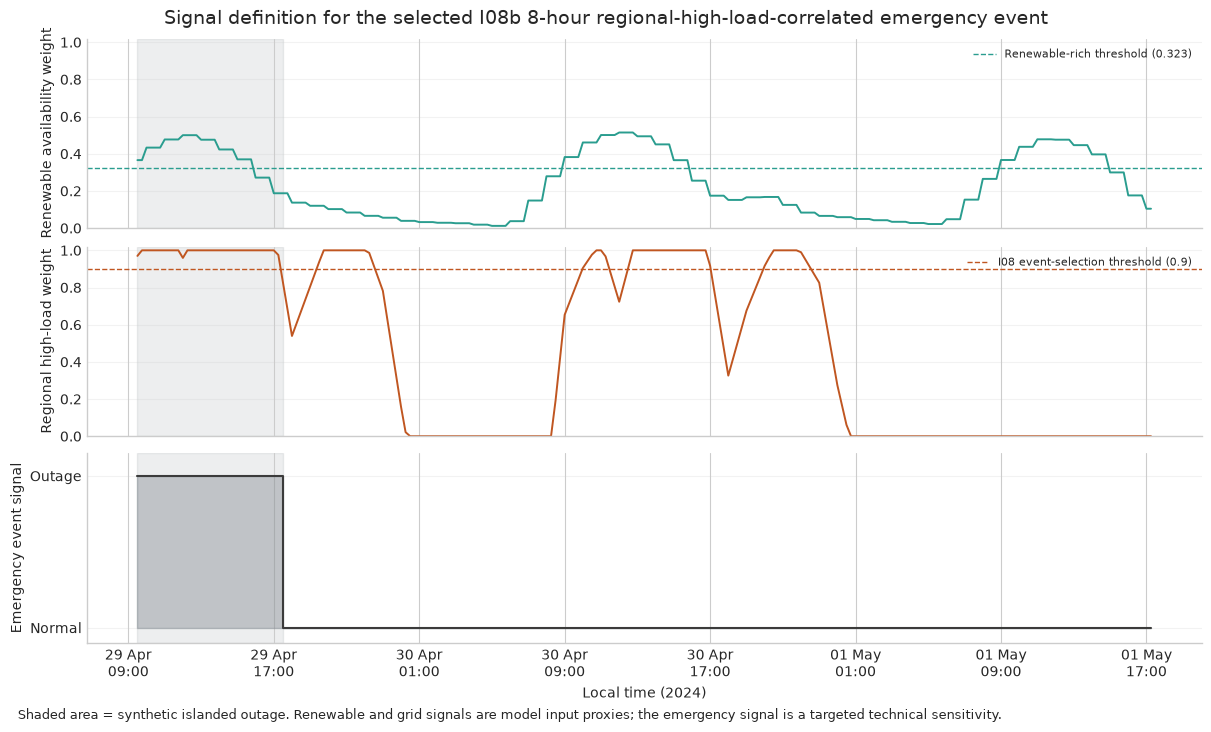

In [593]:
import matplotlib.dates as mdates

renewable_signal_path = INPUT_ROOT / 'building_v2b_renewable_alignment_annual' / 'forecasts_df.csv'
emergency_signal_path = INPUT_ROOT / 'building_v2g_emergency_backup_8h_prepared' / 'forecasts_df.csv'
renewable_signal = pd.read_csv(renewable_signal_path, usecols=['datetime', 'renewable_availability_weight', 'renewable_rich_threshold'], parse_dates=['datetime']).set_index('datetime')
emergency_signal = pd.read_csv(emergency_signal_path, usecols=['datetime', 'grid_congestion_weight', 'synthetic_outage_event', 'grid_connection_available'], parse_dates=['datetime']).set_index('datetime')
signal_window = emergency_signal.join(renewable_signal, how='left')
if signal_window['renewable_availability_weight'].isna().any():
    raise ValueError('Renewable signal does not cover the selected I08 emergency window.')
outage = signal_window['synthetic_outage_event'].astype(bool)
outage_start = signal_window.index[outage][0]
outage_end = signal_window.index[outage][-1] + pd.Timedelta(minutes=15)
renewable_threshold = float(signal_window['renewable_rich_threshold'].iloc[0])

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].plot(signal_window.index, signal_window['renewable_availability_weight'], color='#2a9d8f', linewidth=1.4)
axes[0].axhline(renewable_threshold, color='#2a9d8f', linestyle='--', linewidth=1.0, label=f'Renewable-rich threshold ({renewable_threshold:.3f})')
axes[0].set_ylabel('Renewable availability weight')
axes[0].set_ylim(0, 1.02)
axes[0].legend(loc='upper right', frameon=False, fontsize=8)

axes[1].plot(signal_window.index, signal_window['grid_congestion_weight'], color='#c05621', linewidth=1.4)
axes[1].axhline(0.9, color='#c05621', linestyle='--', linewidth=1.0, label='I08 event-selection threshold (0.9)')
axes[1].set_ylabel('Regional high-load weight')
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc='upper right', frameon=False, fontsize=8)

axes[2].step(signal_window.index, outage.astype(int), where='post', color='#3b3b3b', linewidth=1.5)
axes[2].fill_between(signal_window.index, 0, outage.astype(int), step='post', color='#6c757d', alpha=0.35)
axes[2].set_ylabel('Emergency event signal')
axes[2].set_yticks([0, 1], labels=['Normal', 'Outage'])
axes[2].set_ylim(-0.1, 1.15)
axes[2].set_xlabel('Local time (2024)')

for axis in axes:
    axis.axvspan(outage_start, outage_end, color='#6c757d', alpha=0.12, zorder=0)
    axis.grid(axis='y', alpha=0.25)
    axis.spines[['top', 'right']].set_visible(False)
axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=8))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))
fig.suptitle('Signal definition for the selected I08b 8-hour regional-high-load-correlated emergency event', fontsize=14)
fig.text(0.01, -0.02, 'Shaded area = synthetic islanded outage. Renewable and grid signals are model input proxies; the emergency signal is a targeted technical sensitivity.', fontsize=9)
plt.show()


## Exemplary signal-responsive V2G dispatch

Three separate explanatory figures isolate the three intended V2G responses: regional-high-load import relief, renewable-energy shifting, and islanded emergency capacity. Each date is selected objectively from the completed dispatch result that delivers the greatest relevant service. These are explanatory examples, not annual averages.

In [594]:
"""Deprecated combined exemplary-day plot retained only as notebook history.
baseline_label = 'V1G baseline'
if baseline_label not in dispatch_by_case or example_case_label not in dispatch_by_case:
    print('The exemplary-day plot requires completed I01 and I07e dispatch outputs.')
else:
    baseline_dispatch = dispatch_by_case[baseline_label].copy()
    smart_dispatch = dispatch_by_case[example_case_label].copy()
    shared_index = baseline_dispatch.index.intersection(smart_dispatch.index)
    baseline_dispatch = baseline_dispatch.reindex(shared_index)
    smart_dispatch = smart_dispatch.reindex(shared_index)
    baseline_net_MW = (baseline_dispatch['traction_grid_import_MWh'] - baseline_dispatch['grid_export_MWh']) / 0.25
    smart_net_MW = (smart_dispatch['traction_grid_import_MWh'] - smart_dispatch['grid_export_MWh']) / 0.25
    stressed = smart_dispatch['grid_congestion_weight'] >= smart_dispatch['grid_stress_threshold']
    relief_MWh = ((baseline_net_MW - smart_net_MW) * 0.25).where(stressed, 0.0)
    daily_relief = relief_MWh.groupby(relief_MWh.index.normalize()).sum()
    selected_day = daily_relief.idxmax()
    day_mask = smart_dispatch.index.normalize() == selected_day
    day_baseline_net_MW = baseline_net_MW.loc[day_mask]
    day_smart_net_MW = smart_net_MW.loc[day_mask]
    day_smart = smart_dispatch.loc[day_mask]
    day_relief_MWh = float(daily_relief.loc[selected_day])
    renewable_threshold = float(day_smart['renewable_rich_threshold'].iloc[0])
    grid_threshold = float(day_smart['grid_stress_threshold'].iloc[0])
    charge_MW = day_smart['bus_charge_MWh'] / 0.25
    discharge_MW = day_smart['bus_discharge_MWh'] / 0.25

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, constrained_layout=True)

    axes[0].plot(day_smart.index, day_smart['renewable_availability_weight'], color='#2a9d8f', linewidth=1.6, label='Renewable-availability proxy')
    axes[0].plot(day_smart.index, day_smart['grid_congestion_weight'], color='#c05621', linewidth=1.6, label='Regional high-load proxy')
    axes[0].axhline(renewable_threshold, color='#2a9d8f', linestyle='--', linewidth=0.9, label='Renewable-rich threshold')
    axes[0].axhline(grid_threshold, color='#c05621', linestyle='--', linewidth=0.9, label='Regional high-load threshold')
    axes[0].set_ylabel('Normalised signal')
    axes[0].set_ylim(0, 1.02)
    axes[0].legend(ncol=2, loc='upper left', fontsize=8, frameon=False)

    bar_width = pd.Timedelta(minutes=12)
    axes[1].bar(day_smart.index, charge_MW, width=bar_width, color='#2f5597', alpha=0.85, label='Bus charging')
    axes[1].bar(day_smart.index, -discharge_MW, width=bar_width, color='#7b5ea7', alpha=0.9, label='V2G discharge')
    axes[1].axhline(0, color='#333333', linewidth=0.8)
    axes[1].set_ylabel('Fleet power (MW)')
    soc_axis = axes[1].twinx()
    soc_axis.plot(day_smart.index, day_smart['bus_soc_MWh'], color='#222222', linewidth=1.4, label='Fleet SOC')
    soc_axis.set_ylabel('Fleet SOC (MWh)')
    handles, labels = axes[1].get_legend_handles_labels()
    soc_handles, soc_labels = soc_axis.get_legend_handles_labels()
    axes[1].legend(handles + soc_handles, labels + soc_labels, ncol=3, loc='upper left', fontsize=8, frameon=False)

    axes[2].plot(day_baseline_net_MW.index, day_baseline_net_MW, color='#6c757d', linewidth=1.5, label='I01 V1G net grid import')
    axes[2].plot(day_smart_net_MW.index, day_smart_net_MW, color='#00856a', linewidth=1.7, label='I07e net grid import/export')
    axes[2].fill_between(day_smart_net_MW.index, day_smart_net_MW, day_baseline_net_MW, where=(day_baseline_net_MW > day_smart_net_MW), color='#00856a', alpha=0.20, label='Grid-import relief')
    axes[2].axhline(0, color='#333333', linewidth=0.8)
    axes[2].set_ylabel('Net grid power (MW)')
    axes[2].set_xlabel('Local time (Asia/Bangkok)')
    axes[2].legend(loc='upper left', fontsize=8, frameon=False)

    for axis in axes:
        axis.grid(axis='y', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=3))
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    fig.suptitle(f'Exemplary I07e smart-dispatch day: {selected_day:%d %B %Y} (regional-high-load-period grid relief: {day_relief_MWh:.3f} MWh)', fontsize=14)
    fig.text(0.01, -0.015, 'Top: input proxy signals. Middle: buses charge when energy is available and discharge when dispatched for V2G support. Bottom: the shaded region is the corresponding reduction in net grid import relative to I01.', fontsize=9)
    plt.show()
"""


"Deprecated combined exemplary-day plot retained only as notebook history.\nbaseline_label = 'V1G baseline'\nif baseline_label not in dispatch_by_case or example_case_label not in dispatch_by_case:\n    print('The exemplary-day plot requires completed I01 and I07e dispatch outputs.')\nelse:\n    baseline_dispatch = dispatch_by_case[baseline_label].copy()\n    smart_dispatch = dispatch_by_case[example_case_label].copy()\n    shared_index = baseline_dispatch.index.intersection(smart_dispatch.index)\n    baseline_dispatch = baseline_dispatch.reindex(shared_index)\n    smart_dispatch = smart_dispatch.reindex(shared_index)\n    baseline_net_MW = (baseline_dispatch['traction_grid_import_MWh'] - baseline_dispatch['grid_export_MWh']) / 0.25\n    smart_net_MW = (smart_dispatch['traction_grid_import_MWh'] - smart_dispatch['grid_export_MWh']) / 0.25\n    stressed = smart_dispatch['grid_congestion_weight'] >= smart_dispatch['grid_stress_threshold']\n    relief_MWh = ((baseline_net_MW - smart_net_M

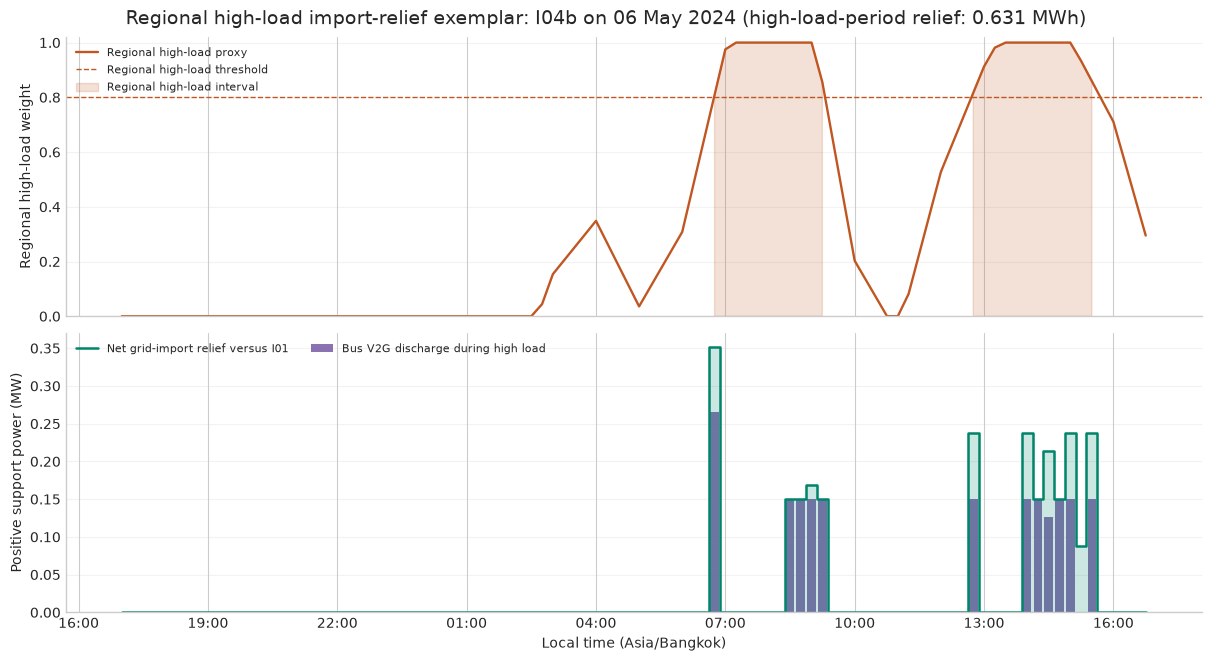

In [595]:
import matplotlib.dates as mdates

grid_case_label = 'I04b maximum regional high-load import relief at 450 kW technical sensitivity'
baseline_label = 'V1G baseline'
if baseline_label not in dispatch_by_case or grid_case_label not in dispatch_by_case:
    print('The regional-high-load exemplar requires completed I01 and I04b dispatch outputs.')
else:
    baseline = dispatch_by_case[baseline_label]
    grid_case = dispatch_by_case[grid_case_label]
    common_index = baseline.index.intersection(grid_case.index)
    baseline = baseline.reindex(common_index)
    grid_case = grid_case.reindex(common_index)
    stress = grid_case['grid_congestion_weight'] >= grid_case['grid_stress_threshold']
    daily_stress_discharge = grid_case['bus_discharge_MWh'].where(stress, 0.0).groupby(grid_case.index.normalize()).sum()
    selected_day = daily_stress_discharge.idxmax()
    day_mask = grid_case.index.normalize() == selected_day
    baseline_net_MW = (baseline['traction_grid_import_MWh'] - baseline['grid_export_MWh']) / 0.25
    case_net_MW = (grid_case['traction_grid_import_MWh'] - grid_case['grid_export_MWh']) / 0.25
    day = grid_case.loc[day_mask]
    day_baseline_net = baseline_net_MW.loc[day_mask]
    day_case_net = case_net_MW.loc[day_mask]
    day_stress = stress.loc[day_mask]
    day_discharge_MW = day['bus_discharge_MWh'] / 0.25
    day_relief_MW = (day_baseline_net - day_case_net).clip(lower=0.0)
    stress_discharge_MW = day_discharge_MW.where(day_stress, 0.0)
    stress_relief_MW = day_relief_MW.where(day_stress, 0.0)
    day_relief_MWh = float(((day_baseline_net - day_case_net) * 0.25).where(day_stress, 0.0).sum())

    fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, constrained_layout=True)
    axes[0].plot(day.index, day['grid_congestion_weight'], color='#c05621', linewidth=1.7, label='Regional high-load proxy')
    axes[0].axhline(float(day['grid_stress_threshold'].iloc[0]), color='#c05621', linestyle='--', linewidth=1.0, label='Regional high-load threshold')
    axes[0].fill_between(day.index, 0, day['grid_congestion_weight'], where=day_stress, color='#c05621', alpha=0.18, label='Regional high-load interval')
    axes[0].set_ylim(0, 1.02)
    axes[0].set_ylabel('Regional high-load weight')
    axes[0].legend(loc='upper left', fontsize=8, frameon=False)

    axes[1].bar(day.index, stress_discharge_MW, width=pd.Timedelta(minutes=12), color='#7b5ea7', alpha=0.88, label='Bus V2G discharge during high load')
    axes[1].step(day.index, stress_relief_MW, where='mid', color='#00856a', linewidth=1.8, label='Net grid-import relief versus I01')
    axes[1].fill_between(day.index, 0, stress_relief_MW, step='mid', color='#00856a', alpha=0.20)
    axes[1].set_ylabel('Positive support power (MW)')
    axes[1].set_xlabel('Local time (Asia/Bangkok)')
    axes[1].legend(ncol=2, loc='upper left', fontsize=8, frameon=False)

    for axis in axes:
        axis.grid(axis='y', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=3))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    fig.suptitle(f'Regional high-load import-relief exemplar: I04b on {selected_day:%d %B %Y} (high-load-period relief: {day_relief_MWh:.3f} MWh)', fontsize=14)
    plt.show()


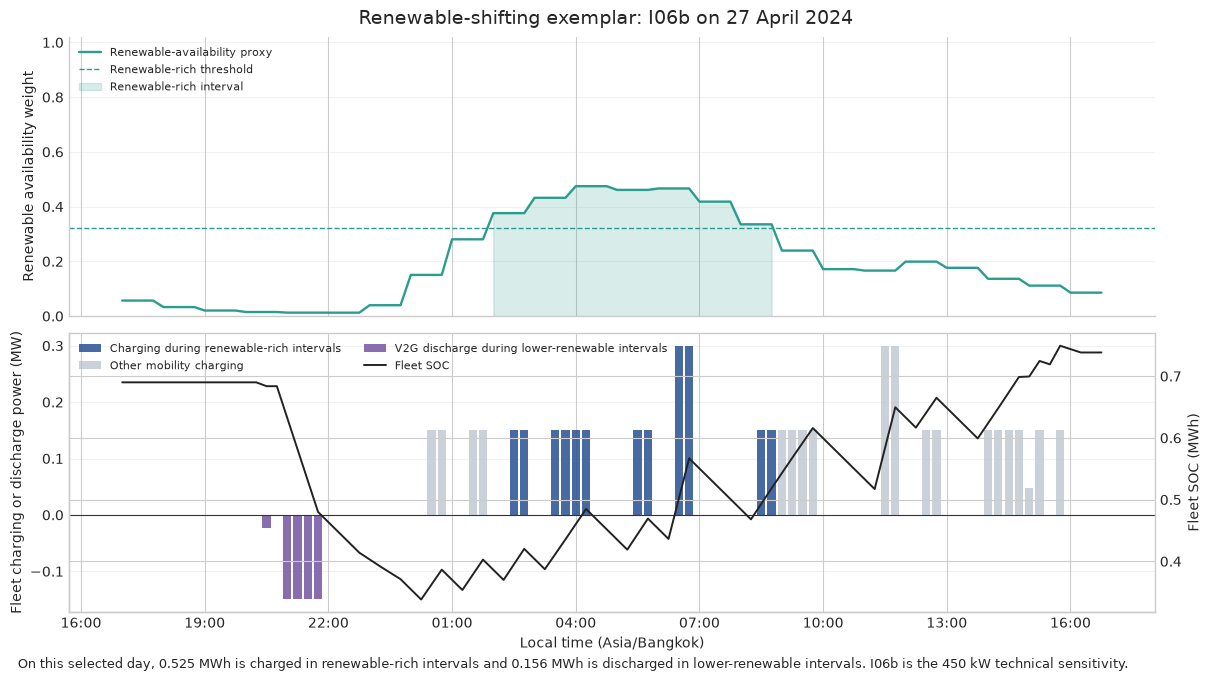

In [596]:
renewable_case_label = 'I06b maximum renewable-deficit support at 450 kW technical sensitivity'
if renewable_case_label not in dispatch_by_case:
    print('The renewable-shifting exemplar requires a completed I06b dispatch output.')
else:
    renewable_case = dispatch_by_case[renewable_case_label]
    renewable_rich = renewable_case['renewable_availability_weight'] >= renewable_case['renewable_rich_threshold']
    daily_renewable_service = (renewable_case['bus_charge_MWh'].where(renewable_rich, 0.0) + renewable_case['bus_discharge_MWh'].where(~renewable_rich, 0.0)).groupby(renewable_case.index.normalize()).sum()
    selected_day = daily_renewable_service.idxmax()
    day_mask = renewable_case.index.normalize() == selected_day
    day = renewable_case.loc[day_mask]
    day_rich = renewable_rich.loc[day_mask]
    charge_MW = day['bus_charge_MWh'] / 0.25
    discharge_MW = day['bus_discharge_MWh'] / 0.25
    rich_charge_MWh = float(day.loc[day_rich, 'bus_charge_MWh'].sum())
    low_renewable_discharge_MWh = float(day.loc[~day_rich, 'bus_discharge_MWh'].sum())

    fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, constrained_layout=True)
    axes[0].plot(day.index, day['renewable_availability_weight'], color='#2a9d8f', linewidth=1.7, label='Renewable-availability proxy')
    axes[0].axhline(float(day['renewable_rich_threshold'].iloc[0]), color='#2a9d8f', linestyle='--', linewidth=1.0, label='Renewable-rich threshold')
    axes[0].fill_between(day.index, 0, day['renewable_availability_weight'], where=day_rich, color='#2a9d8f', alpha=0.18, label='Renewable-rich interval')
    axes[0].set_ylim(0, 1.02)
    axes[0].set_ylabel('Renewable availability weight')
    axes[0].legend(loc='upper left', fontsize=8, frameon=False)

    axes[1].bar(day.index[day_rich], charge_MW.loc[day_rich], width=pd.Timedelta(minutes=12), color='#2f5597', alpha=0.88, label='Charging during renewable-rich intervals')
    axes[1].bar(day.index[~day_rich], charge_MW.loc[~day_rich], width=pd.Timedelta(minutes=12), color='#b9c2cf', alpha=0.75, label='Other mobility charging')
    axes[1].bar(day.index[~day_rich], -discharge_MW.loc[~day_rich], width=pd.Timedelta(minutes=12), color='#7b5ea7', alpha=0.90, label='V2G discharge during lower-renewable intervals')
    axes[1].axhline(0, color='#333333', linewidth=0.8)
    axes[1].set_ylabel('Fleet charging or discharge power (MW)')
    soc_axis = axes[1].twinx()
    soc_axis.plot(day.index, day['bus_soc_MWh'], color='#222222', linewidth=1.4, label='Fleet SOC')
    soc_axis.set_ylabel('Fleet SOC (MWh)')
    handles, labels = axes[1].get_legend_handles_labels()
    soc_handles, soc_labels = soc_axis.get_legend_handles_labels()
    axes[1].legend(handles + soc_handles, labels + soc_labels, ncol=2, loc='upper left', fontsize=8, frameon=False)
    axes[1].set_xlabel('Local time (Asia/Bangkok)')

    for axis in axes:
        axis.grid(axis='y', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=3))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    fig.suptitle(f'Renewable-shifting exemplar: I06b on {selected_day:%d %B %Y}', fontsize=14)
    fig.text(0.01, -0.02, f'On this selected day, {rich_charge_MWh:.3f} MWh is charged in renewable-rich intervals and {low_renewable_discharge_MWh:.3f} MWh is discharged in lower-renewable intervals. I06b is the 450 kW technical sensitivity.', fontsize=9)
    plt.show()


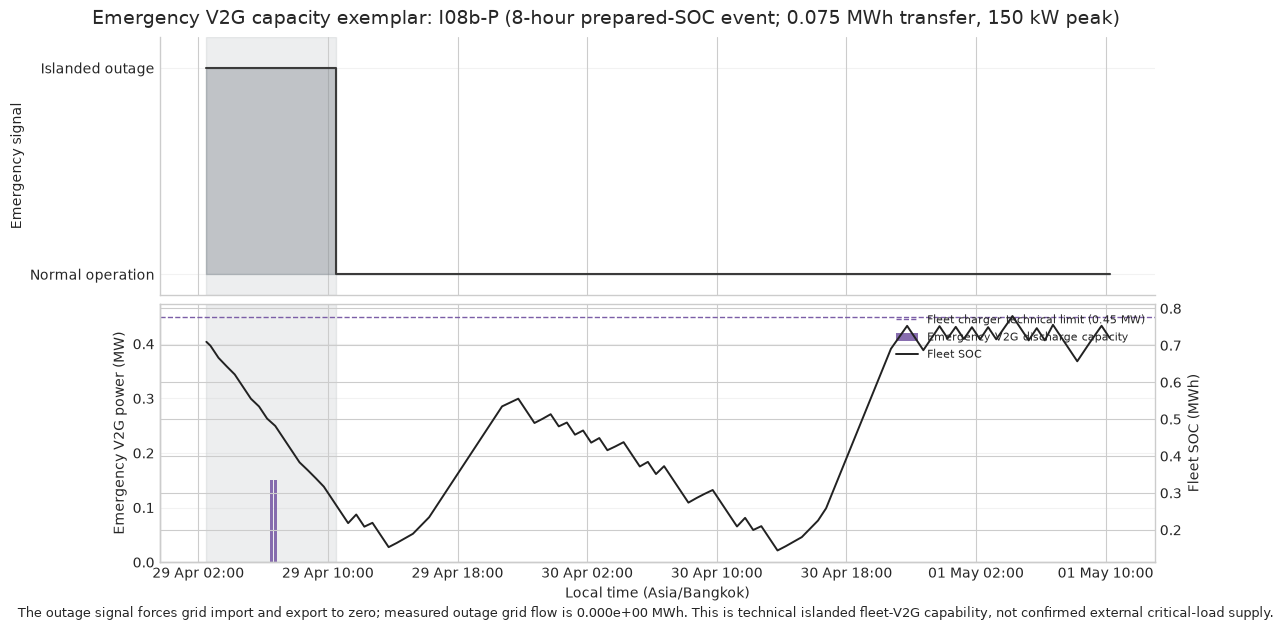

In [597]:
emergency_case_label = 'I08b-P emergency V2G 8 h prepared SOC'
if emergency_case_label not in dispatch_by_case:
    print('The emergency exemplar requires a completed I08b-P dispatch output.')
else:
    emergency_case = dispatch_by_case[emergency_case_label]
    outage = emergency_case['synthetic_outage_event'].astype(bool)
    outage_start = emergency_case.index[outage][0]
    outage_end = emergency_case.index[outage][-1] + pd.Timedelta(minutes=15)
    emergency_power_MW = emergency_case['bus_discharge_MWh'] / 0.25
    peak_emergency_kW = float(emergency_power_MW.loc[outage].max() * 1000.0)
    transfer_MWh = float(emergency_case.loc[outage, 'bus_discharge_MWh'].sum())
    outage_grid_flow_MWh = float((emergency_case.loc[outage, 'grid_import_MWh'] + emergency_case.loc[outage, 'grid_export_MWh']).sum())

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
    axes[0].step(emergency_case.index, outage.astype(int), where='post', color='#3b3b3b', linewidth=1.5)
    axes[0].fill_between(emergency_case.index, 0, outage.astype(int), step='post', color='#6c757d', alpha=0.35)
    axes[0].set_yticks([0, 1], labels=['Normal operation', 'Islanded outage'])
    axes[0].set_ylim(-0.1, 1.15)
    axes[0].set_ylabel('Emergency signal')

    axes[1].bar(emergency_case.index[outage], emergency_power_MW.loc[outage], width=pd.Timedelta(minutes=12), color='#7b5ea7', alpha=0.9, label='Emergency V2G discharge capacity')
    axes[1].axhline(0.45, color='#7b5ea7', linestyle='--', linewidth=1.0, label='Fleet charger technical limit (0.45 MW)')
    axes[1].set_ylabel('Emergency V2G power (MW)')
    axes[1].set_xlabel('Local time (Asia/Bangkok)')
    soc_axis = axes[1].twinx()
    soc_axis.plot(emergency_case.index, emergency_case['bus_soc_MWh'], color='#222222', linewidth=1.4, label='Fleet SOC')
    soc_axis.set_ylabel('Fleet SOC (MWh)')
    handles, labels = axes[1].get_legend_handles_labels()
    soc_handles, soc_labels = soc_axis.get_legend_handles_labels()
    axes[1].legend(handles + soc_handles, labels + soc_labels, loc='upper right', fontsize=8, frameon=False)

    for axis in axes:
        axis.axvspan(outage_start, outage_end, color='#6c757d', alpha=0.12, zorder=0)
        axis.grid(axis='y', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=8))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    fig.suptitle(f'Emergency V2G capacity exemplar: I08b-P (8-hour prepared-SOC event; {transfer_MWh:.3f} MWh transfer, {peak_emergency_kW:.0f} kW peak)', fontsize=14)
    fig.text(0.01, -0.02, f'The outage signal forces grid import and export to zero; measured outage grid flow is {outage_grid_flow_MWh:.3e} MWh. This is technical islanded fleet-V2G capability, not confirmed external critical-load supply.', fontsize=9)
    plt.show()


## Grid-condition relief and renewable-equivalent absorption

The grid figure shows each case's actual signed net grid exchange during regional high-load periods, sorted from export to import. Negative values mean net export to the grid; positive values mean net import from the grid. Green indicates export, grey indicates zero exchange, and red indicates import. A separate figure shows renewable-equivalent charging absorption for the same completed cases. Diesel is excluded because it has no grid connection in the study boundary.


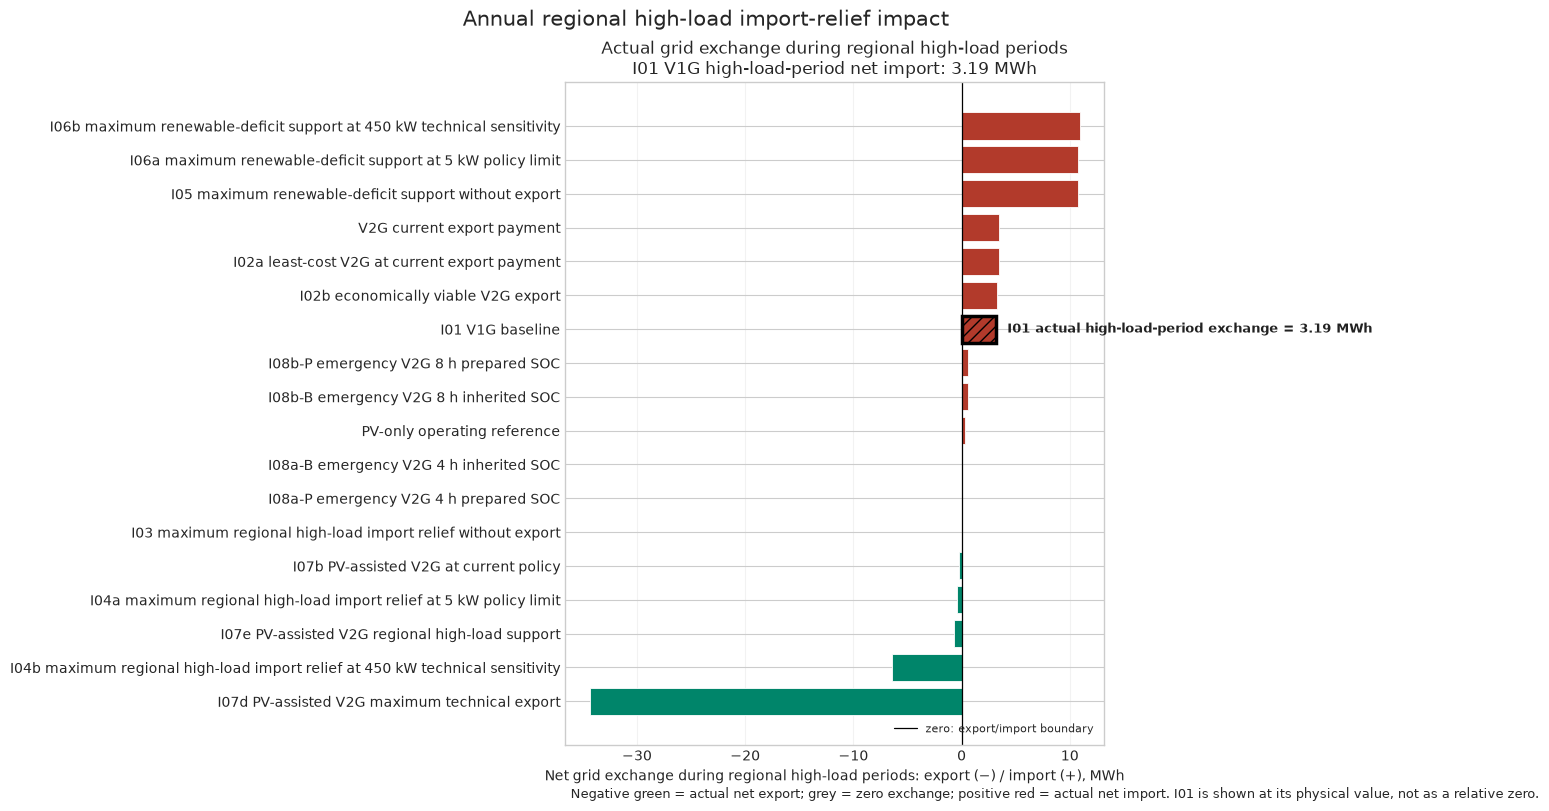

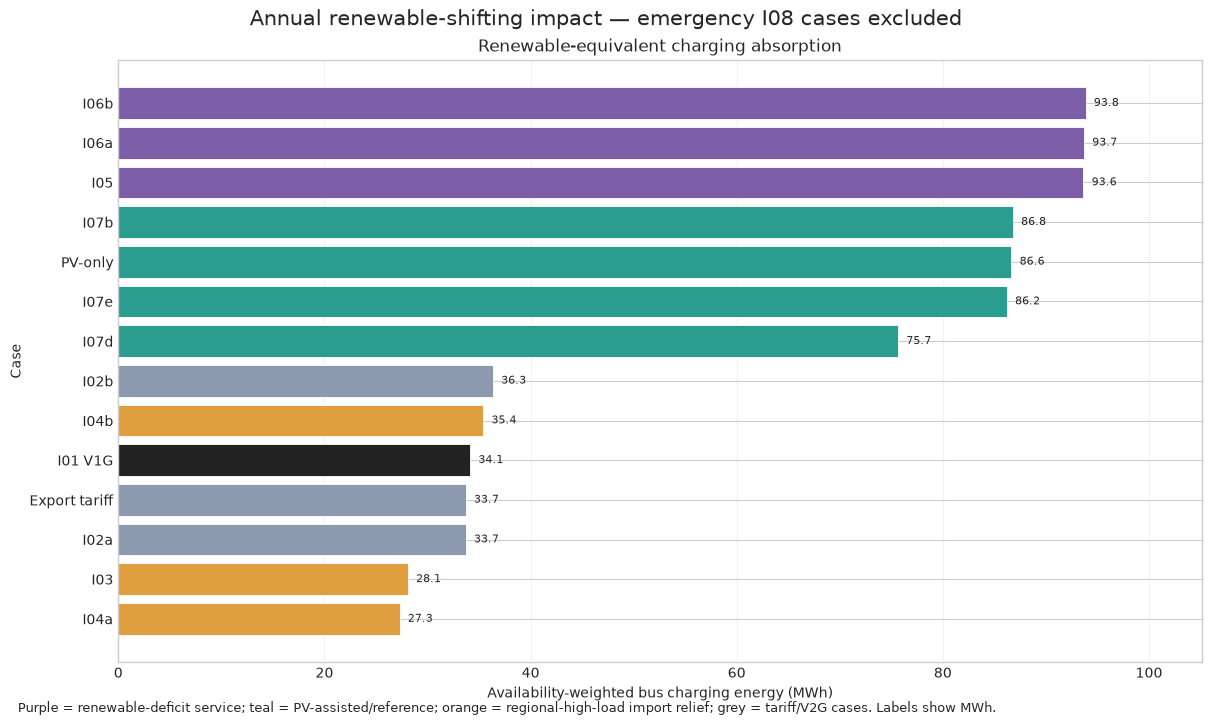

In [598]:
# Regional high-load import-relief indicators are shown as absolute grid exchange during high-load periods.
# I01 is included as the ordinary V1G reference bar.
impact = comparison.drop(index='Diesel benchmark', errors='ignore').copy()
impact = impact.loc[impact.index.intersection(dispatch_by_case)]

figure, axis = plt.subplots(figsize=(14, 8), constrained_layout=True)

stress_rows = []
for label, dispatch in dispatch_by_case.items():
    stress = dispatch['grid_congestion_weight'] >= dispatch['grid_stress_threshold']
    stress_rows.append({
        'scenario': 'I01 V1G baseline' if label == 'V1G baseline' else label,
        'net_grid_exchange_MWh': float(dispatch.loc[stress, 'traction_net_grid_import_MWh'].sum()),
        'bus_discharge_MWh': float(dispatch.loc[stress, 'bus_discharge_MWh'].sum()),
    })
stress_summary = pd.DataFrame(stress_rows).set_index('scenario')
i01_stress_import = float(stress_summary.loc['I01 V1G baseline', 'net_grid_exchange_MWh']) if 'I01 V1G baseline' in stress_summary.index else float('nan')
stress_summary = stress_summary.sort_values('net_grid_exchange_MWh')
stress_impact = stress_summary['net_grid_exchange_MWh']
tolerance = 1e-6
grid_colors = []
for value in stress_impact:
    if value < -tolerance:
        grid_colors.append('#00856a')  # net export
    elif abs(value) <= tolerance:
        grid_colors.append('#7f8c8d')  # zero exchange
    else:
        grid_colors.append('#b23a2b')  # net import
bars = axis.barh(stress_impact.index, stress_impact.values, color=grid_colors, edgecolor='white', linewidth=0.6)
if 'I01 V1G baseline' in stress_impact.index:
    i01_position = list(stress_impact.index).index('I01 V1G baseline')
    bars[i01_position].set_edgecolor('black')
    bars[i01_position].set_linewidth(2.5)
    bars[i01_position].set_hatch('///')
    axis.annotate(f'I01 actual high-load-period exchange = {i01_stress_import:.2f} MWh', xy=(i01_stress_import, i01_position), xytext=(8, 0), textcoords='offset points', va='center', fontsize=9, fontweight='bold', color='#222222')
axis.axvline(0.0, color='black', linewidth=0.9, label='zero: export/import boundary')
axis.set_title(f'Actual grid exchange during regional high-load periods\nI01 V1G high-load-period net import: {i01_stress_import:.2f} MWh')
axis.set_xlabel('Net grid exchange during regional high-load periods: export (−) / import (+), MWh')
axis.legend(fontsize=8, loc='lower right')
axis.text(0.01, -0.08, 'Negative green = actual net export; grey = zero exchange; positive red = actual net import. I01 is shown at its physical value, not as a relative zero.', transform=axis.transAxes, fontsize=9)
axis.grid(axis='x', alpha=0.25)
axis.set_axisbelow(True)

figure.suptitle('Annual regional high-load import-relief impact', fontsize=15)
plt.show()

# Emergency cases are resilience tests, not renewable-shifting cases, so they are not plotted here.
renewable_impact = impact.loc[~impact.index.str.startswith('I08'), 'renewable_absorbed_MWh'].fillna(0.0)
renewable_impact = renewable_impact.sort_values(ascending=True)
renewable_short_labels = {
    'V1G baseline': 'I01 V1G',
    'PV-only operating reference': 'PV-only',
    'V2G current export payment': 'Export tariff',
    'I02a least-cost V2G at current export payment': 'I02a',
    'I02b economically viable V2G export': 'I02b',
    'I03 maximum regional high-load import relief without export': 'I03',
    'I04a maximum regional high-load import relief at 5 kW policy limit': 'I04a',
    'I04b maximum regional high-load import relief at 450 kW technical sensitivity': 'I04b',
    'I05 maximum renewable-deficit support without export': 'I05',
    'I06a maximum renewable-deficit support at 5 kW policy limit': 'I06a',
    'I06b maximum renewable-deficit support at 450 kW technical sensitivity': 'I06b',
    'I07b PV-assisted V2G at current policy': 'I07b',
    'I07d PV-assisted V2G maximum technical export': 'I07d',
    'I07e PV-assisted V2G regional high-load support': 'I07e',
}
renewable_labels = [renewable_short_labels.get(name, name) for name in renewable_impact.index]
renewable_colors = []
for name in renewable_impact.index:
    if name.startswith('I05') or name.startswith('I06'):
        renewable_colors.append('#7b5ea7')
    elif name.startswith('I07') or name == 'PV-only operating reference':
        renewable_colors.append('#2a9d8f')
    elif name.startswith('I03') or name.startswith('I04'):
        renewable_colors.append('#e09f3e')
    elif name.startswith('I02') or name == 'V2G current export payment':
        renewable_colors.append('#8d99ae')
    else:
        renewable_colors.append('#222222')
renewable_figure, renewable_axis = plt.subplots(figsize=(12, 7), constrained_layout=True)
renewable_bars = renewable_axis.barh(renewable_labels, renewable_impact.values, color=renewable_colors, edgecolor='white', linewidth=0.6)
for bar, value in zip(renewable_bars, renewable_impact.values):
    renewable_axis.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f'{value:.1f}', va='center', fontsize=8)
renewable_axis.set_title('Renewable-equivalent charging absorption')
renewable_axis.set_xlabel('Availability-weighted bus charging energy (MWh)')
renewable_axis.set_ylabel('Case')
renewable_axis.set_xlim(0, max(renewable_impact.max() * 1.12, 1.0))
renewable_axis.grid(axis='x', alpha=0.25)
renewable_axis.set_axisbelow(True)
renewable_figure.suptitle('Annual renewable-shifting impact — emergency I08 cases excluded', fontsize=15)
renewable_figure.text(0.01, -0.01, 'Purple = renewable-deficit service; teal = PV-assisted/reference; orange = regional-high-load import relief; grey = tariff/V2G cases. Labels show MWh.', fontsize=9)
plt.show()


## I08 emergency V2G capacity and cost

This resilience-envelope plot combines the technical and operating dimensions of I08. The vertical axis is the maximum emergency V2G power available during the outage, the horizontal axis is the outage duration, bubble area is emergency energy transferred, and colour is the recovery-energy cost gap per transferred kWh relative to matched V1G operation. Prepared-SOC cases assume the event is known in advance; inherited-SOC cases represent normal-operation readiness. I08 remains a technical islanded fleet-to-fleet transfer sensitivity, not confirmed external critical-load supply.

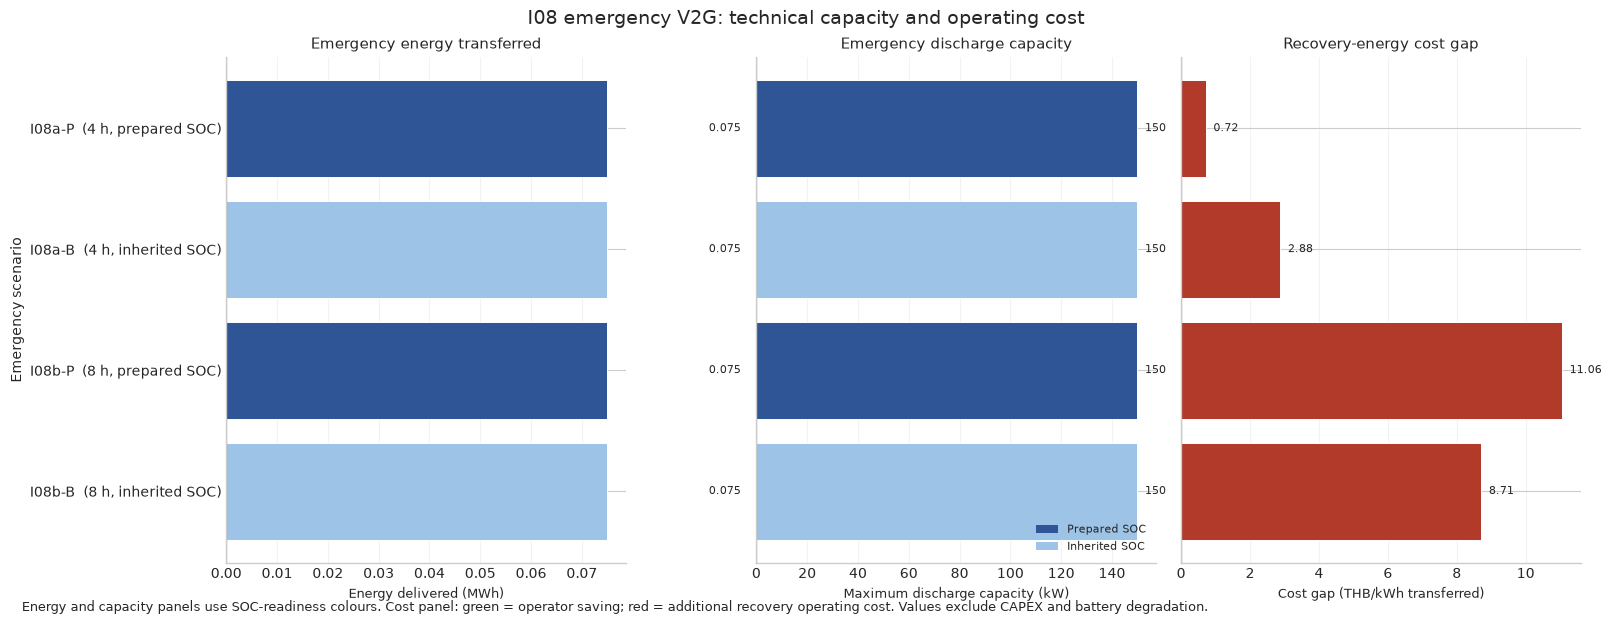

In [599]:
i08_gap = service_cost_gap[service_cost_gap['time_basis'] == 'event'].copy() if not service_cost_gap.empty else pd.DataFrame()
i08_rows = []
for scenario, row in i08_gap.iterrows():
    dispatch = dispatch_by_case.get(scenario)
    if dispatch is None:
        continue
    outage = dispatch.get('synthetic_outage_event', pd.Series(False, index=dispatch.index)).astype(bool)
    i08_rows.append({
        'scenario': scenario,
        'duration_h': float(outage.sum() * 0.25),
        'peak_power_kW': float(row['peak_service_kW']),
        'transfer_MWh': float(row['service_energy_MWh']),
        'cost_gap_per_kWh': float(row['cost_gap_THB_per_service_kWh']),
        'cost_gap_THB': float(row['cost_gap_THB']),
    })
i08_plot = pd.DataFrame(i08_rows).dropna()
if i08_plot.empty:
    print('No completed I08 results are available for the resilience-envelope plot.')
else:
    preferred_order = ['I08a-P emergency V2G 4 h prepared SOC', 'I08a-B emergency V2G 4 h inherited SOC', 'I08b-P emergency V2G 8 h prepared SOC', 'I08b-B emergency V2G 8 h inherited SOC']
    i08_plot['order'] = i08_plot['scenario'].map({name: position for position, name in enumerate(preferred_order)})
    i08_plot = i08_plot.sort_values('order')
    label_map = {
        'I08a-P emergency V2G 4 h prepared SOC': 'I08a-P  (4 h, prepared SOC)',
        'I08a-B emergency V2G 4 h inherited SOC': 'I08a-B  (4 h, inherited SOC)',
        'I08b-P emergency V2G 8 h prepared SOC': 'I08b-P  (8 h, prepared SOC)',
        'I08b-B emergency V2G 8 h inherited SOC': 'I08b-B  (8 h, inherited SOC)',
    }
    i08_plot['label'] = i08_plot['scenario'].map(label_map)
    labels = i08_plot['label'].tolist()[::-1]
    prepared_color = '#2f5597'
    inherited_color = '#9dc3e6'
    soc_colors = [prepared_color if '-P ' in name else inherited_color for name in i08_plot['scenario']][::-1]
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True, constrained_layout=True)
    panels = [
        ('transfer_MWh', 'Emergency energy transferred', 'Energy delivered (MWh)', '{:.3f}'),
        ('peak_power_kW', 'Emergency discharge capacity', 'Maximum discharge capacity (kW)', '{:.0f}'),
        ('cost_gap_per_kWh', 'Recovery-energy cost gap', 'Cost gap (THB/kWh transferred)', '{:.2f}'),
    ]
    for panel_number, (column, title, xlabel, number_format) in enumerate(panels):
        axis = axes[panel_number]
        values = i08_plot[column].to_numpy(dtype=float)[::-1]
        colors = soc_colors if column != 'cost_gap_per_kWh' else ['#00856a' if value < 0 else '#b23a2b' for value in values]
        bars = axis.barh(labels, values, color=colors, edgecolor='white', linewidth=0.7)
        axis.axvline(0, color='#333333', linewidth=0.8)
        span = max(float(np.max(np.abs(values))), 1.0)
        for bar, value in zip(bars, values):
            offset = 0.02 * span if value >= 0 else -0.02 * span
            axis.text(value + offset, bar.get_y() + bar.get_height() / 2, number_format.format(value), va='center', ha='left' if value >= 0 else 'right', fontsize=8)
        axis.set_title(title, fontsize=11)
        axis.set_xlabel(xlabel, fontsize=9)
        axis.grid(axis='x', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    axes[0].set_ylabel('Emergency scenario', fontsize=10)
    from matplotlib.patches import Patch
    axes[1].legend(handles=[Patch(facecolor=prepared_color, label='Prepared SOC'), Patch(facecolor=inherited_color, label='Inherited SOC')], loc='lower right', fontsize=8, frameon=False)
    fig.suptitle('I08 emergency V2G: technical capacity and operating cost', fontsize=14)
    fig.text(0.01, -0.01, 'Energy and capacity panels use SOC-readiness colours. Cost panel: green = operator saving; red = additional recovery operating cost. Values exclude CAPEX and battery degradation.', fontsize=9)
    plt.show()


## 4. Cross-case comparison plots

Operational CO₂ uses the constant grid factor declared above, so the renewable-aware objective is not automatically a carbon result. Replace the constant with an approved time-varying grid-emissions series before using it as a carbon-aware case.

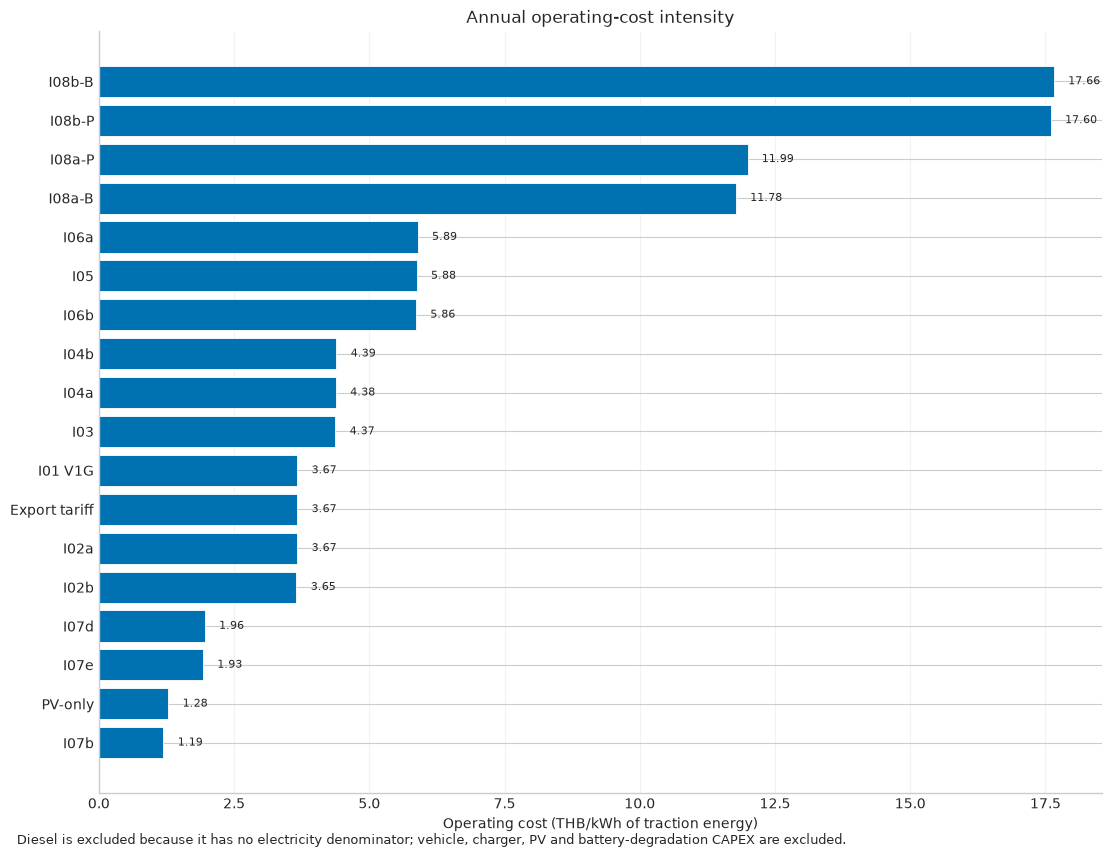

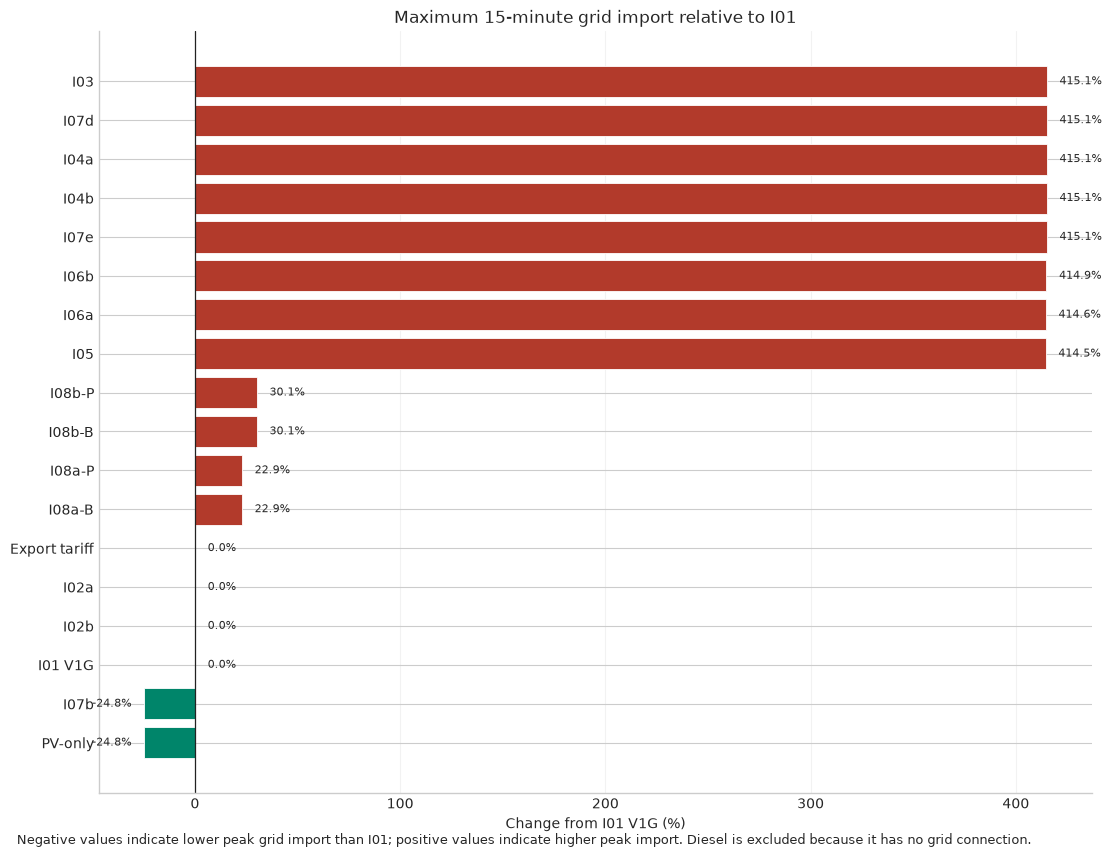

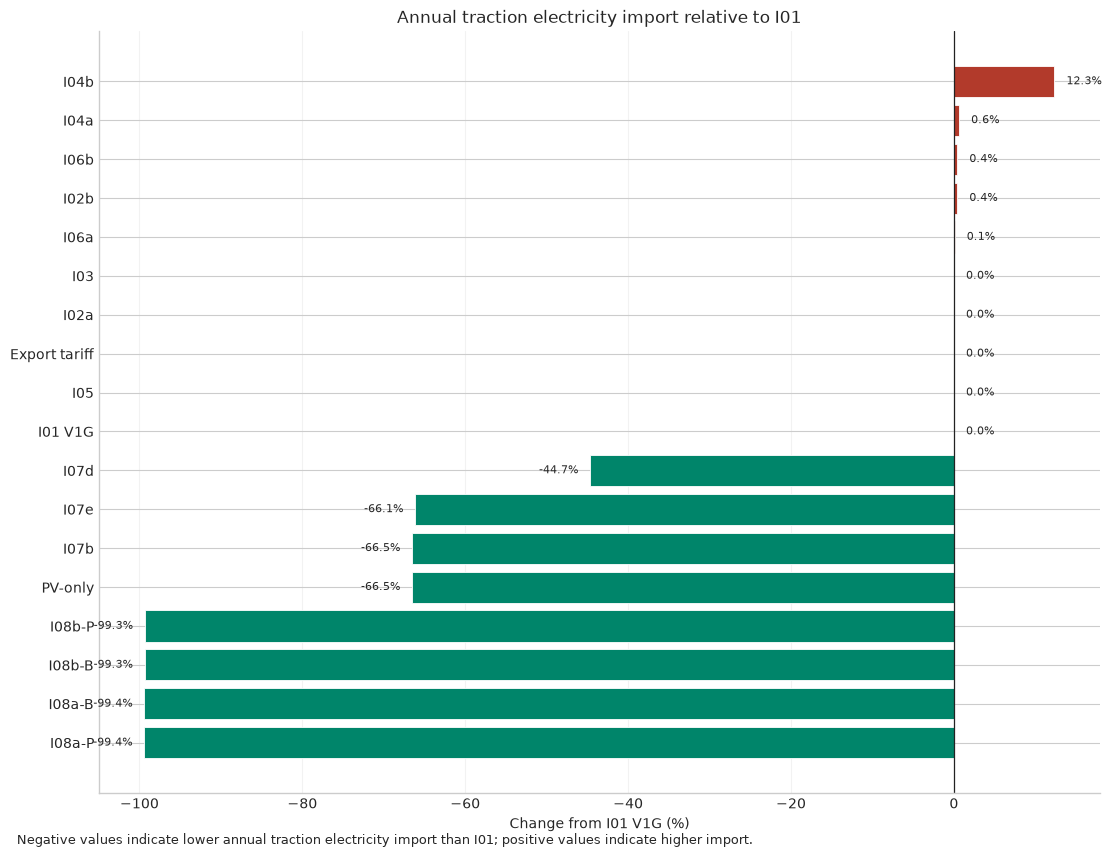

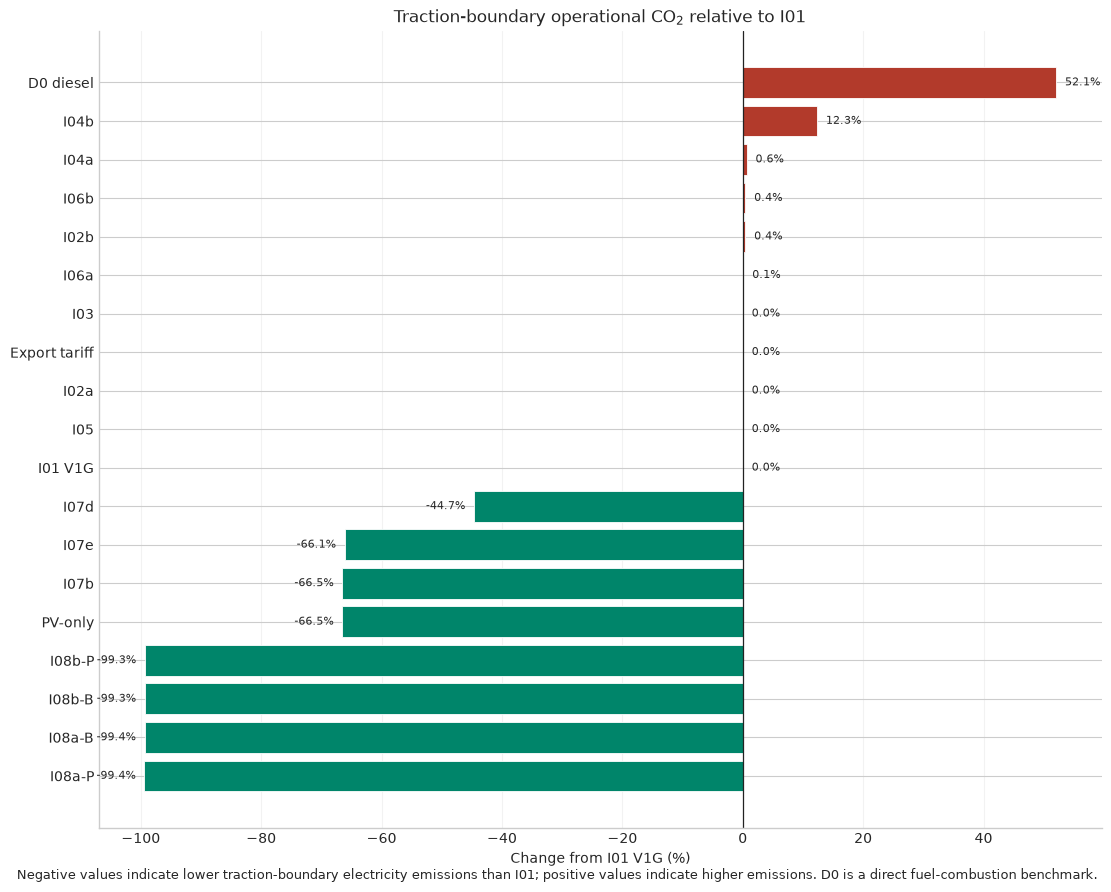

In [600]:
def concise_case_label(name):
    if name == 'Diesel benchmark':
        return 'D0 diesel'
    if name == 'V1G baseline':
        return 'I01 V1G'
    if name == 'PV-only operating reference':
        return 'PV-only'
    if name == 'V2G current export payment':
        return 'Export tariff'
    return name.split()[0]

electric_plot_data = comparison.loc[comparison.index.intersection(dispatch_by_case)].copy()
electric_charge_MWh = pd.Series({label: float(dispatch['bus_charge_MWh'].sum()) for label, dispatch in dispatch_by_case.items()})
electric_plot_data['cost_THB_per_kWh_traction'] = electric_plot_data['total_cost_THB'] / electric_charge_MWh.reindex(electric_plot_data.index) / 1000.0

def academic_bar(values, title, xlabel, colors, relative=False, note=None):
    values = values.dropna().sort_values()
    labels = [concise_case_label(name) for name in values.index]
    fig, axis = plt.subplots(figsize=(11, max(5.5, 0.35 * len(values) + 2)), constrained_layout=True)
    bars = axis.barh(labels, values.values, color=colors.reindex(values.index).values, edgecolor='white', linewidth=0.6)
    if relative:
        axis.axvline(0, color='#222222', linewidth=0.9)
    span = max(float(np.max(np.abs(values.values))), 1.0)
    for bar, value in zip(bars, values.values):
        offset = 0.015 * span if value >= 0 else -0.015 * span
        number = f'{value:.1f}%' if relative else f'{value:.2f}'
        axis.text(value + offset, bar.get_y() + bar.get_height() / 2, number, va='center', ha='left' if value >= 0 else 'right', fontsize=8)
    axis.set_title(title, fontsize=12)
    axis.set_xlabel(xlabel, fontsize=10)
    axis.grid(axis='x', alpha=0.25)
    axis.set_axisbelow(True)
    axis.spines[['top', 'right']].set_visible(False)
    if note:
        fig.text(0.01, -0.01, note, fontsize=9)
    plt.show()

# 1. Cost intensity is reported in THB per kWh of traction energy delivered to the buses.
cost_colors = pd.Series(COLORS['blue'], index=electric_plot_data.index)
academic_bar(electric_plot_data['cost_THB_per_kWh_traction'], 'Annual operating-cost intensity', 'Operating cost (THB/kWh of traction energy)', cost_colors, note='Diesel is excluded because it has no electricity denominator; vehicle, charger, PV and battery-degradation CAPEX are excluded.')

v1g = comparison.loc['V1G baseline']

# 2. Maximum grid import relative to I01. Diesel is excluded because it is not grid-connected.
peak_import_relative = 100.0 * (electric_plot_data['peak_grid_import_MW'] - v1g['peak_grid_import_MW']) / v1g['peak_grid_import_MW']
peak_import_colors = peak_import_relative.map(lambda value: '#00856a' if value < 0 else '#b23a2b')
academic_bar(peak_import_relative, 'Maximum 15-minute grid import relative to I01', 'Change from I01 V1G (%)', peak_import_colors, relative=True, note='Negative values indicate lower peak grid import than I01; positive values indicate higher peak import. Diesel is excluded because it has no grid connection.')

# 3. Annual traction electricity import relative to I01.
annual_import_relative = 100.0 * (electric_plot_data['grid_import_MWh'] - v1g['grid_import_MWh']) / v1g['grid_import_MWh']
annual_import_colors = annual_import_relative.map(lambda value: '#00856a' if value < 0 else '#b23a2b')
academic_bar(annual_import_relative, 'Annual traction electricity import relative to I01', 'Change from I01 V1G (%)', annual_import_colors, relative=True, note='Negative values indicate lower annual traction electricity import than I01; positive values indicate higher import.')

# 4. Traction-boundary operational CO2 relative to I01; D0 is retained as the diesel benchmark.
co2_relative = 100.0 * (comparison['operational_CO2_kg'] - v1g['operational_CO2_kg']) / v1g['operational_CO2_kg']
co2_colors = co2_relative.map(lambda value: '#00856a' if value < 0 else '#b23a2b')
academic_bar(co2_relative, 'Traction-boundary operational CO$_2$ relative to I01', 'Change from I01 V1G (%)', co2_colors, relative=True, note='Negative values indicate lower traction-boundary electricity emissions than I01; positive values indicate higher emissions. D0 is a direct fuel-combustion benchmark.')

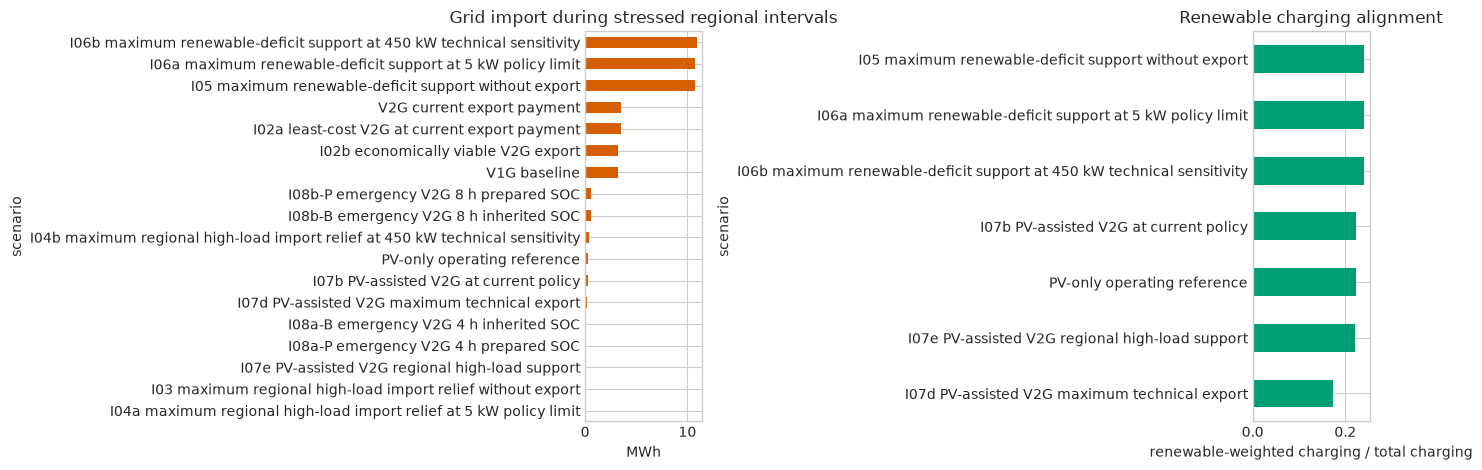

In [601]:
electric_only = comparison.drop(index='Diesel benchmark', errors='ignore')
figure, axes = plt.subplots(1, 2, figsize=(14, 4.8))
electric_only['grid_import_during_stress_MWh'].sort_values().plot.barh(ax=axes[0], color=COLORS['orange'])
axes[0].set_title('Grid import during stressed regional intervals')
axes[0].set_xlabel('MWh')
alignment = electric_only['renewable_alignment_score'].dropna().sort_values()
if not alignment.empty:
    alignment.plot.barh(ax=axes[1], color=COLORS['green'])
    axes[1].set_xlabel('renewable-weighted charging / total charging')
else:
    axes[1].text(0.5, 0.5, 'No renewable KPI in available outputs', ha='center', va='center')
axes[1].set_title('Renewable charging alignment')
figure.tight_layout()
plt.show()

## 5. Representative operation and duration curves

The week plot explains *how* the strategies differ. The load-duration plot uses all 35,136 intervals and therefore complements the annual peak KPI.

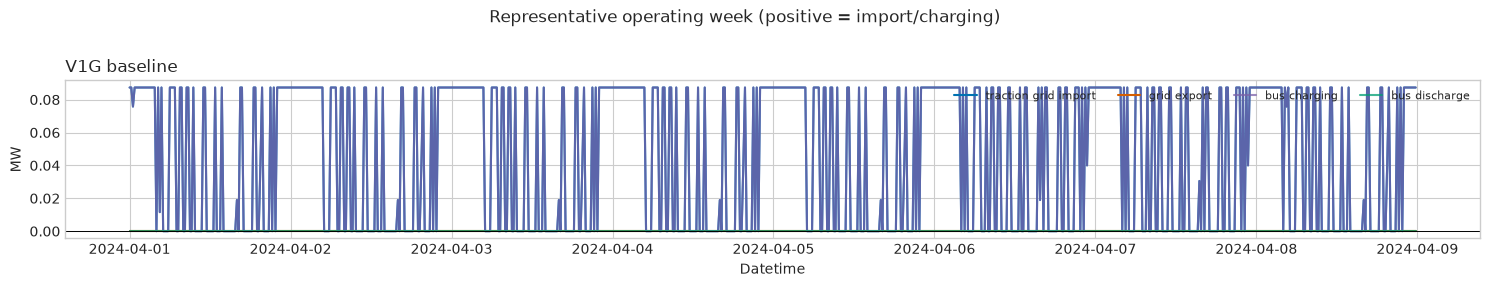

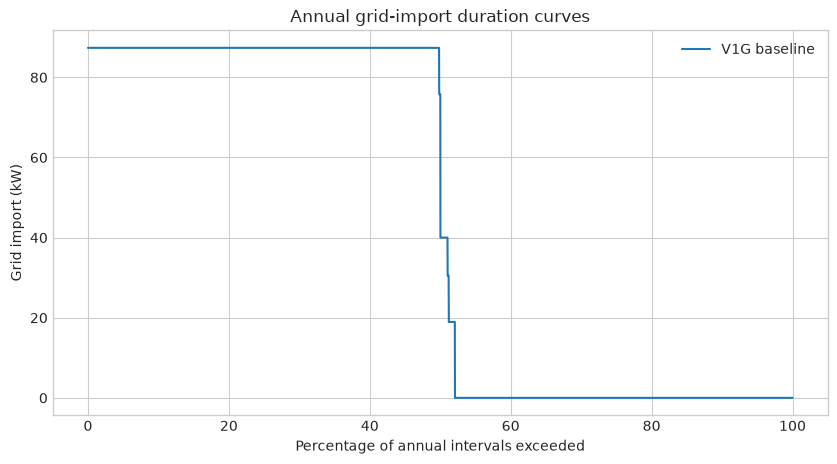

In [602]:
selected_labels = [label for label in ('V1G baseline', 'I02 least-cost V2G export', 'V2B maximum grid relief', 'V2G maximum regional high-load import relief', 'V2B maximum RE shifting', 'V2G maximum RE shifting') if label in dispatch_by_case]
week_start = '2024-04-01'
week_end = '2024-04-08'
if selected_labels:
    figure, axes = plt.subplots(len(selected_labels), 1, figsize=(15, 2.8 * len(selected_labels)), sharex=True, squeeze=False)
    for axis, label in zip(axes[:, 0], selected_labels, strict=False):
        week = dispatch_by_case[label].loc[week_start:week_end]
        axis.plot(week.index, week['traction_grid_import_MW'], label='traction grid import', color=COLORS['blue'])
        axis.plot(week.index, -week['grid_export_MW'], label='grid export', color=COLORS['orange'])
        axis.plot(week.index, week['bus_charge_MWh'] / 0.25, label='bus charging', color=COLORS['purple'], alpha=0.75)
        axis.plot(week.index, -week['bus_discharge_MWh'] / 0.25, label='bus discharge', color=COLORS['green'], alpha=0.75)
        if week['pv_generation_MWh'].max() > 0:
            axis.fill_between(week.index, 0, week['pv_generation_MWh'] / 0.25, color='#F0C808', alpha=0.35, label='PV used')
        axis.axhline(0, color='black', linewidth=0.7)
        axis.set_ylabel('MW')
        axis.set_title(label, loc='left')
    axes[0, 0].legend(ncol=5, fontsize=8, loc='upper right')
    axes[-1, 0].set_xlabel('Datetime')
    figure.suptitle('Representative operating week (positive = import/charging)', y=1.01)
    figure.tight_layout()
    plt.show()

    figure, axis = plt.subplots(figsize=(10, 5))
    for label in selected_labels:
        values = np.sort(dispatch_by_case[label]['traction_grid_import_MW'].to_numpy())[::-1]
        axis.plot(np.linspace(0, 100, len(values)), values * 1000, label=label)
    axis.set(xlabel='Percentage of annual intervals exceeded', ylabel='Grid import (kW)', title='Annual grid-import duration curves')
    axis.legend()
    plt.show()

## 6. Rooftop-PV balance

In [603]:
pv_label = 'V2B rooftop PV'
if pv_label in comparison.index:
    pv = comparison.loc[pv_label]
    pv_balance = pd.Series({'Used on site': pv['pv_used_MWh'], 'Curtailed': pv['pv_curtailment_MWh']})
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].pie(pv_balance, labels=pv_balance.index, autopct='%1.1f%%', colors=[COLORS['green'], '#D1D5DB'], startangle=90)
    axes[0].set_title('Annual PV potential allocation')
    monthly_pv = dispatch_by_case[pv_label].resample('ME')[['pv_available_generation_MWh', 'pv_generation_MWh', 'pv_curtailment_MWh']].sum()
    axes[1].plot(monthly_pv.index, monthly_pv['pv_available_generation_MWh'], marker='o', label='available', color='#E6B800')
    axes[1].plot(monthly_pv.index, monthly_pv['pv_generation_MWh'], marker='o', label='used', color=COLORS['green'])
    axes[1].plot(monthly_pv.index, monthly_pv['pv_curtailment_MWh'], marker='o', label='curtailed', color=COLORS['grey'])
    axes[1].set(title='Monthly rooftop-PV balance', ylabel='MWh')
    axes[1].legend()
    figure.tight_layout()
    plt.show()

renewable_labels = [label for label in ('V2B maximum RE shifting', 'V2G maximum RE shifting') if label in dispatch_by_case]
if renewable_labels:
    figure, axes = plt.subplots(len(renewable_labels), 1, figsize=(13, 3.6 * len(renewable_labels)), sharex=True, squeeze=False)
    for axis, label in zip(axes[:, 0], renewable_labels, strict=False):
        monthly = dispatch_by_case[label].resample('ME')[['renewable_equivalent_charge_MWh', 'renewable_equivalent_discharge_to_site_MWh', 'renewable_equivalent_grid_export_MWh', 'renewable_equivalent_conversion_loss_MWh']].sum()
        axis.plot(monthly.index, monthly['renewable_equivalent_charge_MWh'], marker='o', label='renewable-equivalent absorbed')
        axis.plot(monthly.index, monthly['renewable_equivalent_discharge_to_site_MWh'], marker='o', label='delivered behind meter')
        axis.plot(monthly.index, monthly['renewable_equivalent_grid_export_MWh'], marker='o', label='exported')
        axis.plot(monthly.index, monthly['renewable_equivalent_conversion_loss_MWh'], marker='o', label='conversion loss')
        axis.set_ylabel('MWh')
        axis.set_title(label, loc='left')
        axis.legend(ncol=4, fontsize=8)
    axes[-1, 0].set_xlabel('Month')
    figure.suptitle('Renewable-equivalent energy shifting (proxy accounting)', y=1.01)
    figure.tight_layout()
    plt.show()

## 7. Cartographic view of modeled bus services

The lines below are simplified geographic corridors assembled from documented termini and major corridor points. They support study communication and spatial orientation only. They must not be used for stop-level distance, scheduling, or navigation; replace the GeoJSON with validated GTFS/GPS shapes if these become available. Annual kilometres shown in the labels come from the simulation forecast—not from the map geometry.

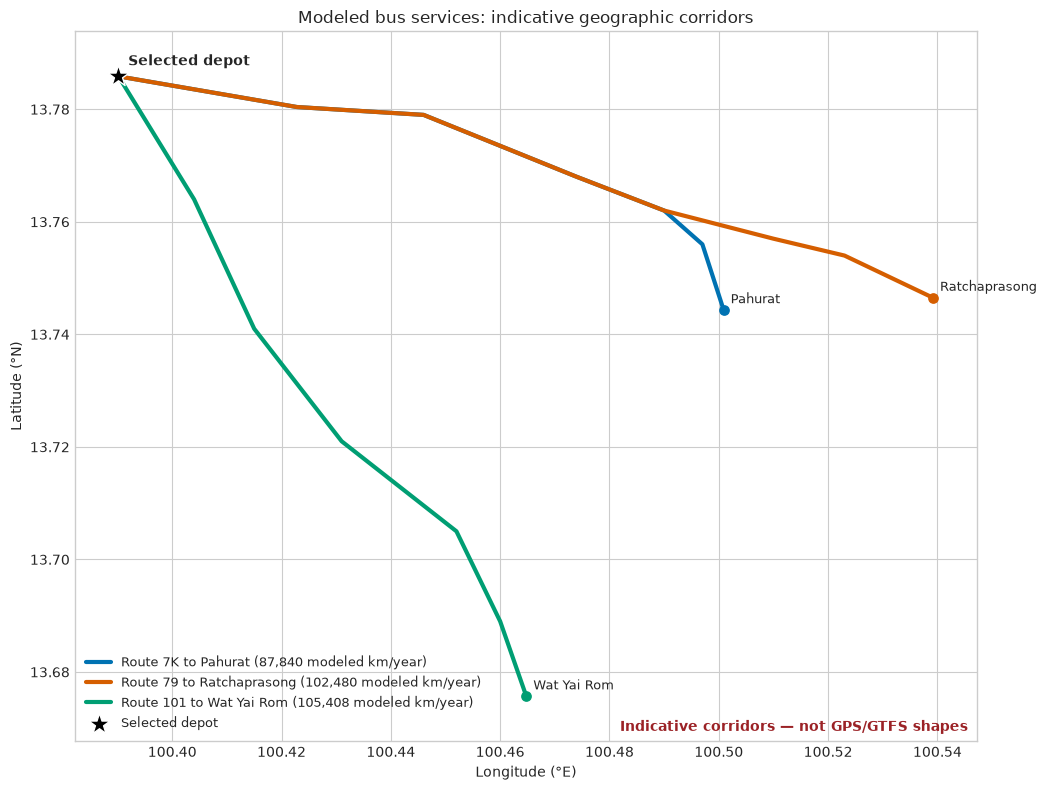

In [604]:
with ROUTE_PATH.open(encoding='utf-8') as stream:
    route_geojson = json.load(stream)
figure, axis = plt.subplots(figsize=(12, 8))
all_lon, all_lat = [], []
for feature in route_geojson['features']:
    coordinates = np.asarray(feature['geometry']['coordinates'])
    properties = feature['properties']
    bus_name = properties['model_bus']
    annual_km = route_totals.get(bus_name, np.nan)
    label = f"Route {properties['route_id']} to {properties['terminus']} ({annual_km:,.0f} modeled km/year)"
    axis.plot(coordinates[:, 0], coordinates[:, 1], linewidth=3, color=properties['color'], label=label)
    axis.scatter(coordinates[-1, 0], coordinates[-1, 1], s=45, color=properties['color'], zorder=4)
    axis.annotate(properties['terminus'], coordinates[-1], xytext=(5, 5), textcoords='offset points', fontsize=9)
    all_lon.extend(coordinates[:, 0])
    all_lat.extend(coordinates[:, 1])
depot_lon, depot_lat = 100.3901683, 13.7858496
axis.scatter(depot_lon, depot_lat, marker='*', s=260, color='black', edgecolor='white', linewidth=1, zorder=5, label='Selected depot')
axis.annotate('Selected depot', (depot_lon, depot_lat), xytext=(7, 8), textcoords='offset points', fontweight='bold')
axis.set_xlim(min(all_lon) - 0.008, max(all_lon) + 0.008)
axis.set_ylim(min(all_lat) - 0.008, max(all_lat) + 0.008)
axis.set_aspect(1 / np.cos(np.deg2rad(np.mean(all_lat))))
axis.set(xlabel='Longitude (°E)', ylabel='Latitude (°N)', title='Modeled bus services: indicative geographic corridors')
axis.legend(loc='lower left', fontsize=9)
axis.text(0.99, 0.01, 'Indicative corridors — not GPS/GTFS shapes', transform=axis.transAxes, ha='right', va='bottom', color='#9B2226', fontweight='bold')
figure.tight_layout()
plt.show()

### Interactive road basemap

This interactive figure is the cartographic companion to the static corridor plot above. It uses the OpenStreetMap road basemap when the notebook is viewed online. The coloured route lines remain indicative study corridors; they are not GPS traces or GTFS shapes.

In [605]:
road_map = go.Figure()
route_km_total = 0.0
for feature in route_geojson['features']:
    coordinates = np.asarray(feature['geometry']['coordinates'])
    properties = feature['properties']
    route_id = properties['route_id']
    terminus = properties['terminus']
    color = properties['color']
    annual_km = float(route_totals.get(properties['model_bus'], 0.0))
    route_km_total += annual_km

    # A pale casing keeps each corridor visible above the road basemap.
    road_map.add_trace(go.Scattermap(
        lon=coordinates[:, 0], lat=coordinates[:, 1], mode='lines',
        line={'width': 10, 'color': 'rgba(255, 255, 255, 0.90)'},
        hoverinfo='skip', showlegend=False,
    ))
    road_map.add_trace(
        go.Scattermap(
            lon=coordinates[:, 0],
            lat=coordinates[:, 1],
            mode='lines+markers',
            line={'width': 5, 'color': color},
            marker={'size': 5, 'color': color},
            name=f"Route {properties['route_id']} — {properties['terminus']}",
            hovertemplate=(
                f"Route {properties['route_id']}<br>Terminus: {properties['terminus']}"
                f'<br>Modeled distance: {annual_km:,.0f} km/year'
                '<br>Indicative service corridor<extra></extra>'
            ),
        )
    )

    # A route identifier and terminus pin make the service pattern legible.
    badge_index = max(1, int((len(coordinates) - 1) * 0.65))
    road_map.add_trace(go.Scattermap(
        lon=[coordinates[badge_index, 0]], lat=[coordinates[badge_index, 1]],
        mode='markers+text',
        marker={'size': 20, 'color': color},
        text=[route_id], textposition='middle center',
        textfont={'color': 'white', 'size': 10}, showlegend=False,
        hovertemplate=f'<b>Route {route_id}</b><br>Outbound to {terminus}<extra></extra>',
    ))
    road_map.add_trace(go.Scattermap(
        lon=[coordinates[-1, 0]], lat=[coordinates[-1, 1]],
        mode='markers+text',
        marker={'size': 13, 'color': color},
        text=[f'{route_id}: {terminus}'], textposition='top right',
        textfont={'color': color, 'size': 11}, showlegend=False,
        hovertemplate=f'<b>Route {route_id} terminus</b><br>{terminus}<extra></extra>',
    ))
# The depot beacon is deliberately drawn last, above all route origins.
road_map.add_trace(go.Scattermap(
    lon=[depot_lon], lat=[depot_lat], mode='markers',
    marker={'size': 38, 'color': '#F4A261'},
    showlegend=False, hoverinfo='skip',
))
road_map.add_trace(
    go.Scattermap(
        lon=[depot_lon],
        lat=[depot_lat],
        mode='markers+text',
        marker={'size': 18, 'color': '#111111'},
        text=['BUS DEPOT'],
        textposition='top right',
        textfont={'color': '#111111', 'size': 14},
        name='Selected depot',
        hovertemplate='<b>Selected depot</b><br>Origin of all modeled services<extra></extra>',
    )
)
road_map.update_layout(
    title={'text': 'Modeled bus-service network <sup>outbound indicative corridors</sup>', 'x': 0.01, 'xanchor': 'left'},
    map={'style': 'open-street-map', 'center': {'lon': 100.465, 'lat': 13.735}, 'zoom': 10.35},
    margin={'l': 0, 'r': 0, 't': 50, 'b': 0},
    legend={'orientation': 'h', 'y': 0.01, 'x': 0.01, 'xanchor': 'left', 'bgcolor': 'rgba(255, 255, 255, 0.85)'},
    annotations=[
        {
            'text': f'3 modeled services | {route_km_total:,.0f} vehicle-km/year',
            'xref': 'paper',
            'yref': 'paper',
            'x': 0.01,
            'y': 0.96,
            'xanchor': 'left',
            'yanchor': 'top',
            'showarrow': False,
            'bgcolor': 'rgba(255, 255, 255, 0.88)',
            'bordercolor': 'rgba(0, 0, 0, 0.18)',
            'borderwidth': 1,
        },
        {
            'text': 'Route lines are indicative corridors, not GPS/GTFS shapes. Map data © OpenStreetMap contributors.',
            'xref': 'paper',
            'yref': 'paper',
            'x': 0.99,
            'y': 0.01,
            'xanchor': 'right',
            'yanchor': 'bottom',
            'showarrow': False,
            'bgcolor': 'rgba(255, 255, 255, 0.80)',
        }
    ],
)
road_map.show()

## 8. Depot roof geometry, usable area, and PV potential

The left panel is a GIS-style plot in local metre coordinates calculated from the roof GeoJSON. It shows measured polygon areas, not a structural suitability survey. The right panel applies the documented 50%, 65%, and 80% usable-roof assumptions and 0.20 kWp/m² module density.

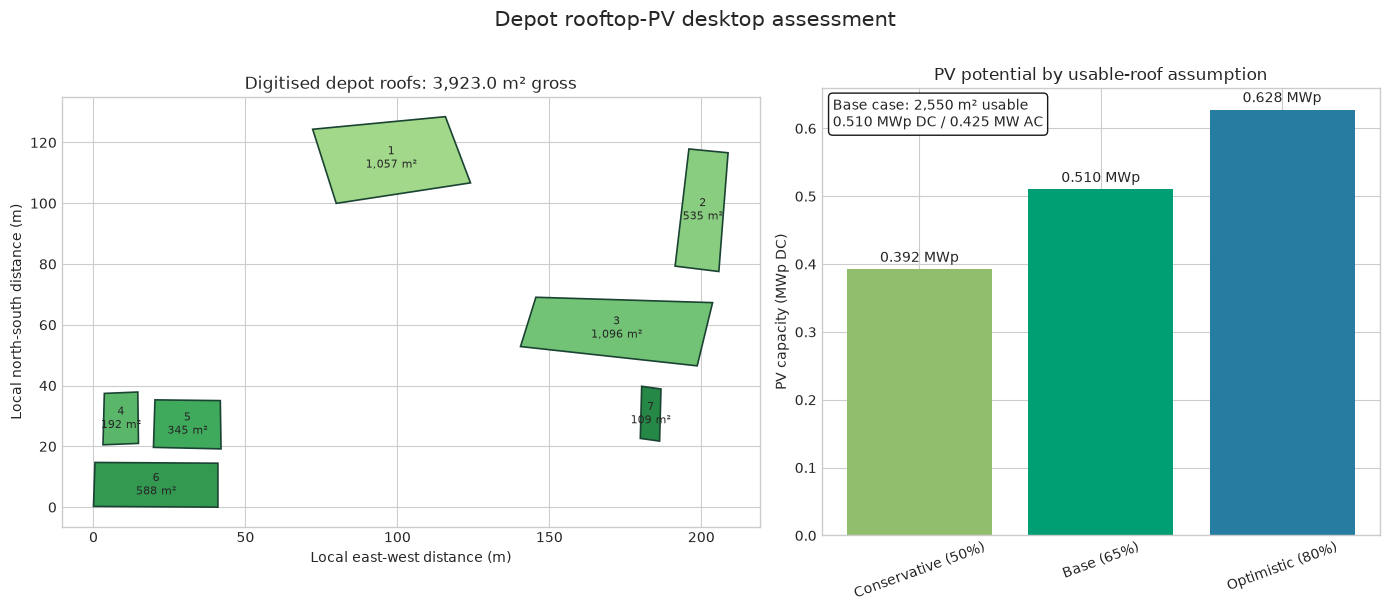

,usable_fraction,usable_area_m2,pv_capacity_mwp_dc,inverter_capacity_mw_ac
Conservative (50%),0.50,1961.50,0.392,0.327
Base (65%),0.65,2549.95,0.510,0.425
Optimistic (80%),0.80,3138.40,0.628,0.523


In [606]:
with ROOF_PATH.open(encoding='utf-8') as stream:
    roof_geojson = json.load(stream)
features = roof_geojson['features']
all_coordinates = np.vstack([np.asarray(feature['geometry']['coordinates'][0]) for feature in features])
origin_lon, origin_lat = all_coordinates[:, 0].min(), all_coordinates[:, 1].min()
metres_per_degree_lat = 111_320
metres_per_degree_lon = metres_per_degree_lat * np.cos(np.deg2rad(origin_lat))
gross_area_m2 = sum(float(feature['properties']['gross_area_m2']) for feature in features)
usable_fractions = pd.Series({'Conservative (50%)': 0.50, 'Base (65%)': 0.65, 'Optimistic (80%)': 0.80})
pv_capacity_mwp = gross_area_m2 * usable_fractions * 0.20 / 1000
figure, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.25, 1]})
for index, feature in enumerate(features, start=1):
    lon_lat = np.asarray(feature['geometry']['coordinates'][0])
    x = (lon_lat[:, 0] - origin_lon) * metres_per_degree_lon
    y = (lon_lat[:, 1] - origin_lat) * metres_per_degree_lat
    area = float(feature['properties']['gross_area_m2'])
    axes[0].fill(x, y, color=plt.cm.YlGn(0.35 + 0.055 * index), edgecolor='#1B4332', linewidth=1.2)
    axes[0].text(x[:-1].mean(), y[:-1].mean(), f'{index}\n{area:,.0f} m²', ha='center', va='center', fontsize=8)
axes[0].set_aspect('equal')
axes[0].set(xlabel='Local east-west distance (m)', ylabel='Local north-south distance (m)', title=f'Digitised depot roofs: {gross_area_m2:,.1f} m² gross')
bars = axes[1].bar(pv_capacity_mwp.index, pv_capacity_mwp.values, color=['#90BE6D', COLORS['green'], '#277DA1'])
axes[1].bar_label(bars, labels=[f'{value:.3f} MWp' for value in pv_capacity_mwp], padding=3)
axes[1].set(ylabel='PV capacity (MWp DC)', title='PV potential by usable-roof assumption')
axes[1].tick_params(axis='x', rotation=20)
base_dc_mwp = float(pv_capacity_mwp['Base (65%)'])
base_usable_area_m2 = gross_area_m2 * float(usable_fractions['Base (65%)'])
axes[1].text(0.02, 0.98, f'Base case: {base_usable_area_m2:,.0f} m² usable\n{base_dc_mwp:.3f} MWp DC / {base_dc_mwp / 1.20:.3f} MW AC', transform=axes[1].transAxes, va='top', bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9})
figure.suptitle('Depot rooftop-PV desktop assessment', fontsize=15, y=1.01)
figure.tight_layout()
plt.show()
roof_table = pd.DataFrame({'usable_fraction': usable_fractions, 'usable_area_m2': gross_area_m2 * usable_fractions, 'pv_capacity_mwp_dc': pv_capacity_mwp, 'inverter_capacity_mw_ac': pv_capacity_mwp / 1.20})
display(roof_table.round(3))

### Interactive satellite roof map

This map places the digitised roof polygons on satellite imagery for visual context. Hover over a roof to see its gross area and its indicative base-case PV capacity. It is a desktop screening figure: imagery dates can vary by tile and zoom, and neither the imagery nor the polygons establish structural suitability, ownership, shading, or a construction design.

In [607]:
roof_center = all_coordinates.mean(axis=0)
base_usable_fraction = 0.65
module_density_kwp_per_m2 = 0.20

satellite_roof_map = go.Figure()
for index, feature in enumerate(features, start=1):
    coordinates = np.asarray(feature['geometry']['coordinates'][0])
    properties = feature['properties']
    gross_roof_area_m2 = float(properties['gross_area_m2'])
    base_pv_kwp = gross_roof_area_m2 * base_usable_fraction * module_density_kwp_per_m2
    satellite_roof_map.add_trace(
        go.Scattermap(
            lon=coordinates[:, 0], lat=coordinates[:, 1], mode='lines', fill='toself',
            fillcolor='rgba(46, 204, 113, 0.34)',
            line={'color': '#0B5345', 'width': 2},
            name=f'Roof {index}',
            hovertemplate=(
                f'<b>Roof {index}</b><br>Gross area: {gross_roof_area_m2:,.1f} m²'
                f'<br>Base-case PV potential: {base_pv_kwp:,.1f} kWp DC'
                '<br>Usable-roof assumption: 65%<extra></extra>'
            ),
        )
    )

satellite_roof_map.add_trace(
    go.Scattermap(
        lon=[roof_center[0]], lat=[roof_center[1]], mode='markers', name='Depot',
        marker={'size': 11, 'color': '#C0392B'},
        hovertemplate='<b>Depot roof cluster</b><extra></extra>',
    )
)
satellite_roof_map.update_layout(
    title='Depot roofs and indicative PV potential',
    map={
        'style': 'white-bg',
        'center': {'lon': roof_center[0], 'lat': roof_center[1]},
        'zoom': 17.2,
        'layers': [{
            'sourcetype': 'raster',
            'source': ['https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'],
            'below': 'traces',
        }],
    },
    margin={'l': 0, 'r': 0, 't': 45, 'b': 0},
    legend={'orientation': 'h', 'y': 0.01, 'x': 0.01},
    annotations=[{
        'text': ('Imagery sources: Esri, DigitalGlobe, GeoEye, i-cubed, USDA FSA, USGS, AEX, '
                 'Getmapping, Aerogrid, IGN, IGP, swisstopo, and the GIS User Community. '
                 'Visual reference only; imagery date not confirmed.'),
        'xref': 'paper', 'yref': 'paper', 'x': 0.01, 'y': 0.02,
        'xanchor': 'left', 'yanchor': 'bottom', 'showarrow': False,
        'font': {'size': 9, 'color': '#1F2937'},
        'bgcolor': 'rgba(255, 255, 255, 0.82)',
    }],
)
satellite_roof_map.show()

## 9. Optional strategy sensitivities

The maximum grid-support and renewable-shifting configurations compare no export, the 5 kW policy sensitivity, and the 450 kW charger-based technical limit. The tariff cases retain the separate export-payment increments. Set `RUN_SENSITIVITY_CASES = True` and run the next cell to calculate missing outputs. Renewable quantities are availability-weighted technical proxies, not measured national curtailment.

/tmp/ipykernel_1690424/3209296242.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_1690424/3209296242.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_1690424/3209296242.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

Missing Export +2.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_2000
Missing Export +2.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_2500
Missing Export +3.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_3000
Missing Export +3.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_3500
Missing Export +4.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_4000
Missing Export +4.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_4500
Missing Export +5.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_5000


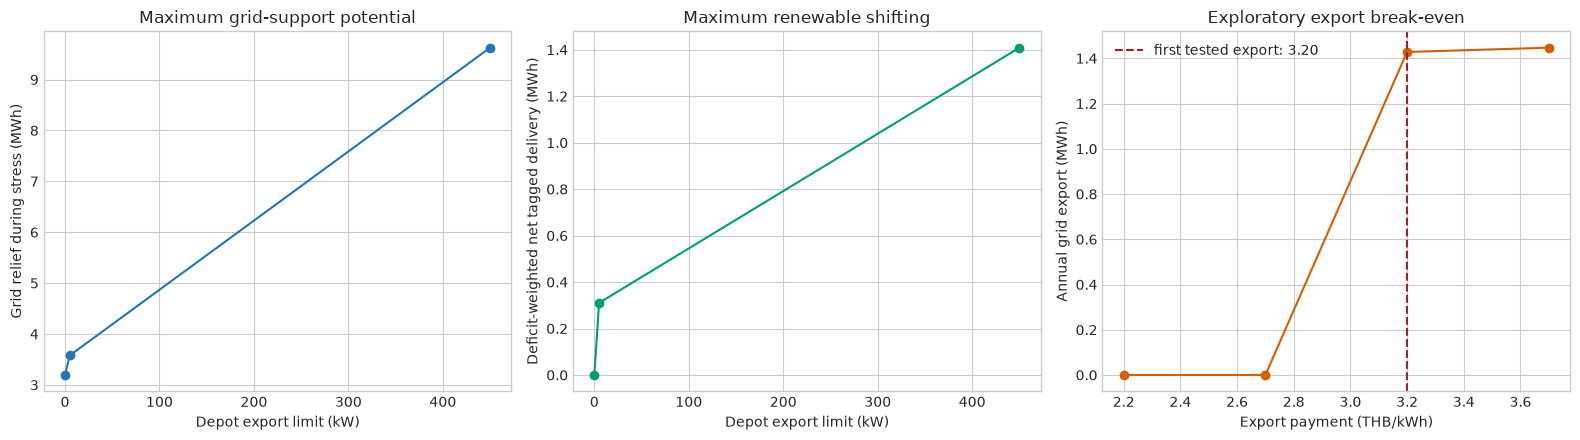

In [608]:
def sensitivity_frame(cases: dict, parameter: str) -> pd.DataFrame:
    rows = []
    for label, spec in cases.items():
        run_case(label, spec, RUN_SENSITIVITY_CASES)
        loaded = load_result(label, spec)
        if loaded is None:
            continue
        row, dispatch = loaded
        if 'V1G baseline' in dispatch_by_case:
            baseline = dispatch_by_case['V1G baseline']
            common_index = baseline.index.intersection(dispatch.index)
            relief = baseline.loc[common_index, 'net_grid_import_MWh'] - dispatch.loc[common_index, 'net_grid_import_MWh']
            threshold = float(dispatch.loc[common_index, 'grid_stress_threshold'].iloc[0])
            stressed = dispatch.loc[common_index, 'grid_congestion_weight'] >= threshold
            row['grid_support_during_stress_MWh'] = float(relief.loc[stressed].sum())
        row[parameter] = spec[parameter]
        rows.append(row)
    return pd.DataFrame(rows).sort_values(parameter) if rows else pd.DataFrame()

grid_sensitivity = sensitivity_frame(GRID_SUPPORT_CASES, 'export_limit_kw')
renewable_sensitivity = sensitivity_frame(RENEWABLE_CASES, 'export_limit_kw')
tariff_sensitivity = sensitivity_frame(TARIFF_CASES, 'increment_thb_per_kwh')
figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))
if not grid_sensitivity.empty:
    axes[0].plot(grid_sensitivity['export_limit_kw'], grid_sensitivity['grid_support_during_stress_MWh'], marker='o')
    axes[0].set(xlabel='Depot export limit (kW)', ylabel='Grid relief during stress (MWh)', title='Maximum grid-support potential')
else:
    axes[0].text(0.5, 0.5, 'Sensitivity outputs not run', ha='center')
if not renewable_sensitivity.empty:
    axes[1].plot(renewable_sensitivity['export_limit_kw'], renewable_sensitivity['renewable_deficit_support_MWh'], marker='o', color=COLORS['green'])
    axes[1].set(xlabel='Depot export limit (kW)', ylabel='Deficit-weighted net tagged delivery (MWh)', title='Maximum renewable shifting')
else:
    axes[1].text(0.5, 0.5, 'Sensitivity outputs not run', ha='center')
if not tariff_sensitivity.empty:
    axes[2].plot(tariff_sensitivity['increment_thb_per_kwh'] + 2.20, tariff_sensitivity['grid_export_MWh'], marker='o', color=COLORS['orange'])
    axes[2].set(xlabel='Export payment (THB/kWh)', ylabel='Annual grid export (MWh)', title='Exploratory export break-even')
    exported = tariff_sensitivity.loc[tariff_sensitivity['grid_export_MWh'] > 1e-6]
    if not exported.empty:
        break_even = 2.20 + float(exported.iloc[0]['increment_thb_per_kwh'])
        axes[2].axvline(break_even, color='#9B2226', linestyle='--', label=f'first tested export: {break_even:.2f}')
        axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'Tariff sweep outputs not run', ha='center')
figure.tight_layout()
plt.show()

## 10. Interpretation checklist

1. Confirm all compared cases cover identical dates, route kilometres, fleet rows, and charger rows.
2. Report energy charges and monthly demand charges separately.
3. Use V1G as the electric operational reference and diesel as the drivetrain benchmark.
4. Keep grid-support, renewable-aware, and cost objectives distinct; a renewable proxy is not an emissions factor.
5. State clearly that the route corridors are indicative and that rooftop capacity requires site and structural surveys.
6. Keep operational costs and emissions separate from investment, lifecycle emissions, maintenance, and any later financial assessment.

## 11. Completed-case executive results

Only folders containing both a summary and dispatch result are analysed below. Pending cases are displayed explicitly and are not assigned zero values. Renewable indicators are availability-weighted technical proxies, not claims about traced renewable electrons. I08 measures islanded fleet-to-fleet V2G transfer capability: it is not a simulation of an external critical load.

In [609]:
availability = result_availability(CORE_CASES, OUTPUT_ROOT)
display(availability)

executive_columns = [
    'distance_km', 'total_cost_THB', 'grid_import_MWh', 'grid_export_MWh',
    'peak_grid_import_MW', 'peak_grid_export_MW', 'operational_CO2_kg',
    'pv_used_MWh', 'pv_curtailment_MWh', 'renewable_absorbed_MWh',
    'renewable_deficit_support_MWh', 'unmet_trip_energy_MWh',
    'synthetic_outage_duration_hours', 'emergency_transfer_MWh',
    'peak_emergency_transfer_MW', 'recovery_grid_import_MWh',
]
display(comparison.reindex(columns=executive_columns).round(3))

pending = availability.index[availability['status'] != 'complete'].tolist()
print(f'Completed outputs analysed: {(availability["status"] == "complete").sum()}/{len(availability)}.')
if pending:
    print('Pending / unavailable outputs excluded from results:', '; '.join(pending))
mobility_failures = comparison.index[comparison['unmet_trip_energy_MWh'].fillna(0) > 1e-9].tolist()
print('Mobility compliance:', 'all loaded cases meet trip energy' if not mobility_failures else f'unmet trip energy in {mobility_failures}')
emergency_cases = comparison[comparison['synthetic_outage_duration_hours'] > 0]
if not emergency_cases.empty:
    print('I08 scope: reported emergency transfer is technical islanded fleet-to-fleet capability; no external critical-load service is represented.')


,output_folder,summary_available,dispatch_available,status
scenario,,,,
V1G baseline,v1g_baseline,True,True,complete
PV-only operating reference,v2b_rooftop_pv,True,True,complete
I02a least-cost V2G at current export payment,v2b_cost,True,True,complete
I02b economically viable V2G export,tariff_plus_1000,True,True,complete
I03 maximum regional high-load import relief without export,grid_support_no_export,True,True,complete
I04a maximum regional high-load import relief at 5 kW policy limit,grid_support_export_5kw,True,True,complete
I04b maximum regional high-load import relief at 450 kW technical sensitivity,grid_support_export_450kw,True,True,complete
I05 maximum renewable-deficit support without export,renewable_shifting_no_export,True,True,complete
I06a maximum renewable-deficit support at 5 kW policy limit,renewable_shifting_export_5kw,True,True,complete


,distance_km,total_cost_THB,grid_import_MWh,grid_export_MWh,peak_grid_import_MW,peak_grid_export_MW,operational_CO2_kg,pv_used_MWh,pv_curtailment_MWh,renewable_absorbed_MWh,renewable_deficit_support_MWh,unmet_trip_energy_MWh,synthetic_outage_duration_hours,emergency_transfer_MWh,peak_emergency_transfer_MW,recovery_grid_import_MWh
scenario,,,,,,,,,,,,,,,,
Diesel benchmark,295728.00,3698339.576,0.000,0.000,0.000,NaN,295771.227,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V1G baseline,295728.00,1427478.195,389.116,0.000,0.087,0.000,194518.983,0.000,0.000,34.137,0.000,0.0,0.0,0.000,0.00,0.000
PV-only operating reference,295728.00,499935.082,130.293,0.000,0.066,0.000,65133.394,258.823,491.432,86.647,0.000,0.0,0.0,0.000,0.00,0.000
I02a least-cost V2G at current export payment,295728.00,1427477.456,389.116,0.000,0.087,0.000,194519.012,0.000,0.000,33.704,0.000,0.0,0.0,0.000,0.00,0.000
I02b economically viable V2G export,295728.00,1427339.981,390.699,1.428,0.087,0.005,195310.251,0.000,0.000,36.348,0.000,0.0,0.0,0.000,0.00,0.000
I03 maximum regional high-load import relief without export,295728.00,1701587.657,389.121,0.000,0.450,0.000,194521.439,0.000,0.000,28.093,0.000,0.0,0.0,0.000,0.00,0.000
I04a maximum regional high-load import relief at 5 kW policy limit,295728.00,1717952.279,391.561,2.160,0.450,0.005,195741.131,0.000,0.000,27.289,0.000,0.0,0.0,0.000,0.00,0.000
I04b maximum regional high-load import relief at 450 kW technical sensitivity,295728.00,1920703.130,437.116,43.304,0.450,0.300,218514.265,0.000,0.000,35.406,0.000,0.0,0.0,0.000,0.00,0.000
I05 maximum renewable-deficit support without export,295728.00,2286272.436,389.116,0.000,0.450,0.000,194518.998,0.000,0.000,93.640,0.000,0.0,0.0,0.000,0.00,0.000


Completed outputs analysed: 18/19.
Pending / unavailable outputs excluded from results: I07c PV-assisted V2G at viable export tariff
Mobility compliance: all loaded cases meet trip energy
I08 scope: reported emergency transfer is technical islanded fleet-to-fleet capability; no external critical-load service is represented.


## 12. Cost gap for non-revenue services

The cost gap is the operator's operating-cost difference from the relevant least-cost mobility baseline. It is a compensation indicator, not a market-clearing price, capital-cost estimate, or Thai tariff recommendation. Annual cases report THB/kWh of modelled service and THB/kW-year; emergency cases report THB/kWh of emergency transfer and THB/kW-event. A missing unit value means that no measurable externally delivered service exists under the zero non-traction-load boundary.

,service_type,comparison_basis,time_basis,cost_gap_THB,service_energy_MWh,peak_service_kW,cost_gap_THB_per_service_kWh,cost_gap_THB_per_kW_year,cost_gap_THB_per_kW_event,potential_monthly_demand_charge_exposure_THB,unit_cost_status,islanding_check
scenario,,,,,,,,,,,,
I05 maximum renewable-deficit support without export,renewable-equivalent proxy service,V1G baseline,annual,858794.242,0.000,87.368,NaN,NaN,NaN,NaN,compensation gap,NaN
I06a maximum renewable-deficit support at 5 kW policy limit,renewable-equivalent proxy service,V1G baseline,annual,868405.891,0.310,92.369,2798.459,9401.525,NaN,NaN,compensation gap,NaN
I06b maximum renewable-deficit support at 450 kW technical sensitivity,renewable-equivalent proxy service,V1G baseline,annual,863240.541,1.409,330.443,612.787,2612.375,NaN,NaN,compensation gap,NaN
I07b PV-assisted V2G at current policy,PV-assisted V2G export,PV-only operating reference,annual,-35287.023,16.028,5.000,-2.202,-7057.405,NaN,NaN,operator saving,NaN
I07d PV-assisted V2G maximum technical export,PV-assisted V2G export,PV-only operating reference,annual,351410.043,165.590,450.000,2.122,780.911,NaN,NaN,compensation gap,NaN
I08a-P emergency V2G 4 h prepared SOC,stress-correlated emergency transfer,matched V1G event-and-recovery window,event,53.678,0.075,150.000,0.716,NaN,0.358,4200.000,recovery-energy compensation gap,pass
I08a-B emergency V2G 4 h inherited SOC,stress-correlated emergency transfer,matched V1G event-and-recovery window,event,215.921,0.075,150.000,2.879,NaN,1.439,4200.000,recovery-energy compensation gap,pass
I08b-P emergency V2G 8 h prepared SOC,stress-correlated emergency transfer,matched V1G event-and-recovery window,event,829.089,0.075,150.000,11.056,NaN,5.527,5526.316,recovery-energy compensation gap,pass
I08b-B emergency V2G 8 h inherited SOC,stress-correlated emergency transfer,matched V1G event-and-recovery window,event,653.260,0.075,150.000,8.711,NaN,4.355,5526.316,recovery-energy compensation gap,pass


I08 demand-charge values are potential monthly exposure only: whether a charge is actually incurred depends on the unmodelled monthly maximum outside the event window.


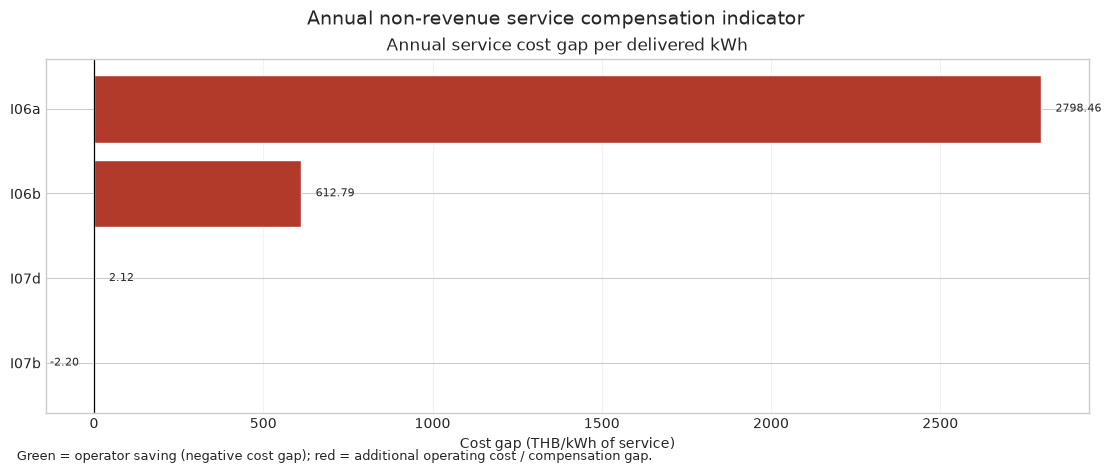

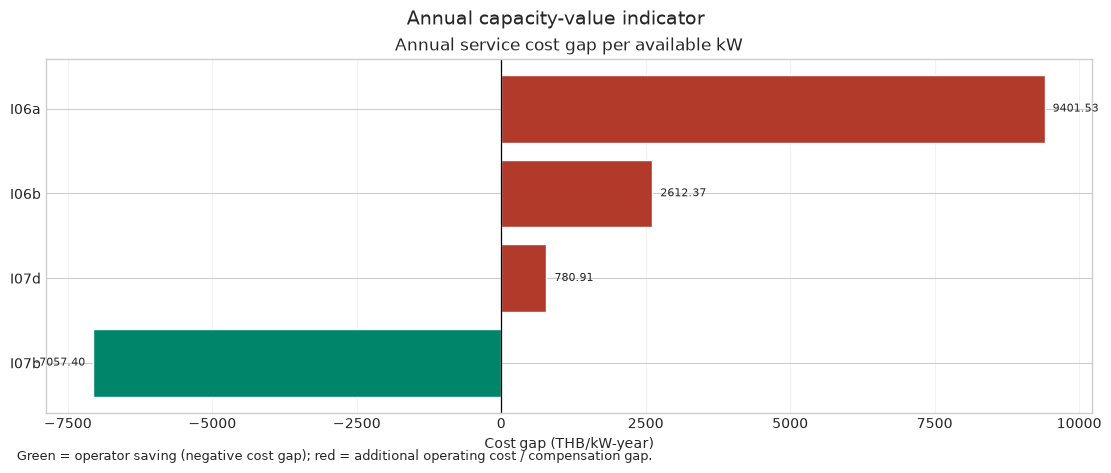

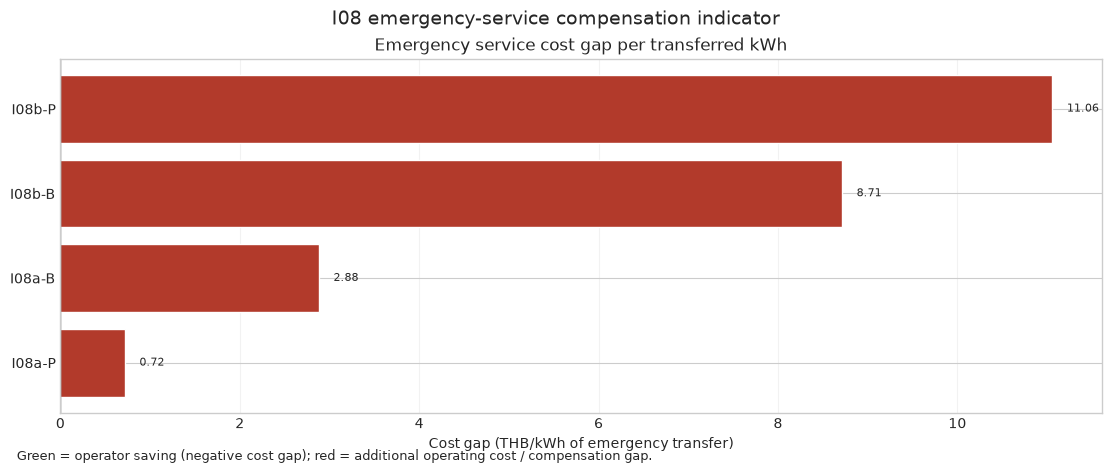

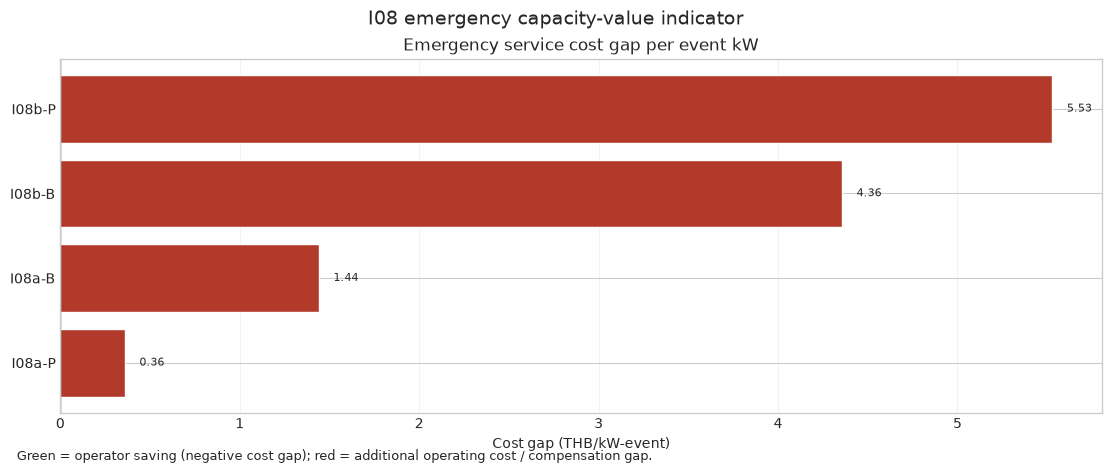

In [610]:
service_cost_gap = build_service_cost_gap(comparison, dispatch_by_case)
if service_cost_gap.empty:
    print('No completed non-revenue service cases are available.')
else:
    cost_gap_columns = [
        'service_type', 'comparison_basis', 'time_basis', 'cost_gap_THB',
        'service_energy_MWh', 'peak_service_kW', 'cost_gap_THB_per_service_kWh',
        'cost_gap_THB_per_kW_year', 'cost_gap_THB_per_kW_event',
        'potential_monthly_demand_charge_exposure_THB', 'unit_cost_status', 'islanding_check',
    ]
    display(service_cost_gap.reindex(columns=cost_gap_columns).round(3))
    emergency_gap = service_cost_gap[service_cost_gap['time_basis'] == 'event']
    if not emergency_gap.empty:
        print('I08 demand-charge values are potential monthly exposure only: whether a charge is actually incurred depends on the unmodelled monthly maximum outside the event window.')
        if not (emergency_gap['islanding_check'] == 'pass').all():
            raise AssertionError('I08 islanding validation failed: non-zero grid flow during an outage.')

# Cost-gap visualisations use only defined service denominators. Negative values are operator savings.
def _plot_cost_gap(frame, value_column, title, xlabel, figure_title):
    plotted = frame[np.isfinite(frame[value_column])].copy()
    if plotted.empty:
        print(f'No defined values available for {title}.')
        return
    plotted = plotted.sort_values(value_column)
    short = {
        'I03 maximum regional high-load import relief without export': 'I03',
        'I04a maximum regional high-load import relief at 5 kW policy limit': 'I04a',
        'I04b maximum regional high-load import relief at 450 kW technical sensitivity': 'I04b',
        'I05 maximum renewable-deficit support without export': 'I05',
        'I06a maximum renewable-deficit support at 5 kW policy limit': 'I06a',
        'I06b maximum renewable-deficit support at 450 kW technical sensitivity': 'I06b',
        'I07b PV-assisted V2G at current policy': 'I07b',
        'I07c PV-assisted V2G at viable export tariff': 'I07c',
        'I07d PV-assisted V2G maximum technical export': 'I07d',
        'I07e PV-assisted V2G regional high-load support': 'I07e',
        'I08a-P emergency V2G 4 h prepared SOC': 'I08a-P',
        'I08a-B emergency V2G 4 h inherited SOC': 'I08a-B',
        'I08b-P emergency V2G 8 h prepared SOC': 'I08b-P',
        'I08b-B emergency V2G 8 h inherited SOC': 'I08b-B',
    }
    labels = [short.get(name, name) for name in plotted.index]
    values = plotted[value_column].to_numpy(dtype=float)
    colors = ['#00856a' if value < 0 else '#b23a2b' for value in values]
    fig, ax = plt.subplots(figsize=(11, max(4.5, 0.42 * len(plotted) + 1.5)), constrained_layout=True)
    bars = ax.barh(labels, values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.9)
    span = max(float(np.max(np.abs(values))), 1.0)
    for bar, value in zip(bars, values):
        offset = 0.015 * span if value >= 0 else -0.015 * span
        ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f'{value:.2f}', va='center', ha='left' if value >= 0 else 'right', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', alpha=0.25)
    ax.set_axisbelow(True)
    fig.suptitle(figure_title, fontsize=14)
    fig.text(0.01, -0.01, 'Green = operator saving (negative cost gap); red = additional operating cost / compensation gap.', fontsize=9)
    plt.show()

if not service_cost_gap.empty:
    annual_gap = service_cost_gap[service_cost_gap['time_basis'] == 'annual']
    event_gap = service_cost_gap[service_cost_gap['time_basis'] == 'event']
    _plot_cost_gap(annual_gap, 'cost_gap_THB_per_service_kWh', 'Annual service cost gap per delivered kWh', 'Cost gap (THB/kWh of service)', 'Annual non-revenue service compensation indicator')
    _plot_cost_gap(annual_gap, 'cost_gap_THB_per_kW_year', 'Annual service cost gap per available kW', 'Cost gap (THB/kW-year)', 'Annual capacity-value indicator')
    _plot_cost_gap(event_gap, 'cost_gap_THB_per_service_kWh', 'Emergency service cost gap per transferred kWh', 'Cost gap (THB/kWh of emergency transfer)', 'I08 emergency-service compensation indicator')
    _plot_cost_gap(event_gap, 'cost_gap_THB_per_kW_event', 'Emergency service cost gap per event kW', 'Cost gap (THB/kW-event)', 'I08 emergency capacity-value indicator')


## 13. Thailand benefit and beneficiary analysis

The current tariff leaves most non-revenue grid, renewable-alignment, and resilience value with the power system or public sector while the fleet operator bears the operating cost and SOC-readiness burden. The preceding cost-gap table therefore identifies the operational payment evidence required for a future measured energy-service or availability-service product.

The relevant distribution utility is conditional on location: PEA serves provincial areas outside Bangkok, Nonthaburi, and Samut Prakan; MEA serves the metropolitan service area. EGAT is relevant to national system operation and transmission; ERC regulates energy-industry operation and tariff-related rules. These institutional roles do not establish permission for the modelled V2G services. [PEA service territory](https://www.pea.co.th/about-pea/pea-service), [EGAT transmission and system control](https://www.egat.co.th/home/en/transmission-line/), and [ERC statutory role](https://www.erc.or.th/en/history-page).

No avoided network investment, external critical-load value, battery degradation, charger/PV CAPEX, or social value is monetised here. Network benefit requires local validation, telemetry, protection, settlement rules, and an approved operating agreement.

In [611]:
display(stakeholder_matrix())

if not service_cost_gap.empty:
    beneficiary_evidence = service_cost_gap[['service_type', 'time_basis', 'service_energy_MWh', 'peak_service_kW', 'cost_gap_THB', 'cost_gap_THB_per_service_kWh']].copy()
    beneficiary_evidence['who_benefits'] = np.where(
        beneficiary_evidence['service_type'].str.contains('emergency'),
        'Passengers / transport authority / resilience planners',
        np.where(beneficiary_evidence['service_type'].str.contains('PV'), 'Depot/PV owner and utility', 'Distribution utility / system operator'),
    )
    beneficiary_evidence['who_bears_operating_gap_now'] = 'Fleet / depot operator unless a service contract pays it'
    display(beneficiary_evidence.round(3))


,benefit,responsibility / exposure,decision-relevant metric
stakeholder,,,
Fleet / public-bus operator,Mobility-compliant charging; any operating saving,"SOC readiness, recovery energy and peak-demand...",Energy-service THB/kWh; availability THB/kW-ye...
"Depot owner, PV owner and charging-service provider","PV utilisation, controlled export and service ...","Charger controls, metering, protection and set...",PV-V2G service cost-gap metric
PEA or MEA distribution utility,Potential local stressed-period net-import relief,"Connection approval, local-network validation ...",Verified grid-service THB/kWh and availability...
EGAT system operator,Potential system-support signal response,Dispatch coordination; no claimed avoided tran...,Only after a defined system-service product
"ERC, EPPO and Ministry of Energy","Evidence for pilot tariff, settlement and cons...","Interconnection, measurement, allocation of va...","Use cost gaps as procurement evidence, not tar..."
"Passengers, transport authorities and wider society","Mobility continuity, resilience insight and lo...",No external critical-load or social value mone...,Public value remains unpriced in this operatio...


,service_type,time_basis,service_energy_MWh,peak_service_kW,cost_gap_THB,cost_gap_THB_per_service_kWh,who_benefits,who_bears_operating_gap_now
scenario,,,,,,,,
I05 maximum renewable-deficit support without export,renewable-equivalent proxy service,annual,0.000,87.368,858794.242,NaN,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I06a maximum renewable-deficit support at 5 kW policy limit,renewable-equivalent proxy service,annual,0.310,92.369,868405.891,2798.459,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I06b maximum renewable-deficit support at 450 kW technical sensitivity,renewable-equivalent proxy service,annual,1.409,330.443,863240.541,612.787,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I07b PV-assisted V2G at current policy,PV-assisted V2G export,annual,16.028,5.000,-35287.023,-2.202,Depot/PV owner and utility,Fleet / depot operator unless a service contra...
I07d PV-assisted V2G maximum technical export,PV-assisted V2G export,annual,165.590,450.000,351410.043,2.122,Depot/PV owner and utility,Fleet / depot operator unless a service contra...
I08a-P emergency V2G 4 h prepared SOC,stress-correlated emergency transfer,event,0.075,150.000,53.678,0.716,Passengers / transport authority / resilience ...,Fleet / depot operator unless a service contra...
I08a-B emergency V2G 4 h inherited SOC,stress-correlated emergency transfer,event,0.075,150.000,215.921,2.879,Passengers / transport authority / resilience ...,Fleet / depot operator unless a service contra...
I08b-P emergency V2G 8 h prepared SOC,stress-correlated emergency transfer,event,0.075,150.000,829.089,11.056,Passengers / transport authority / resilience ...,Fleet / depot operator unless a service contra...
I08b-B emergency V2G 8 h inherited SOC,stress-correlated emergency transfer,event,0.075,150.000,653.260,8.711,Passengers / transport authority / resilience ...,Fleet / depot operator unless a service contra...
